# Descarga efectiva y transporte de sedimentos en el rio Magdalena

## Primer Entregable del Proyecto de Investigacion

**Autores:** Kevin Clemente y Manuel Meza

| | |
|---|---|
| **Ruta metodologica** | A (clasificacion) + Seccion 2.6 (componente temporal) |
| **Fuente de datos** | IDEAM - DHIME |
| **Estacion objetivo** | CALAMAR (29037020), rio Magdalena |
| **Semilla aleatoria** | 42 |

---

### Pregunta de investigacion

> Es posible clasificar, con la informacion hidrologica disponible hasta el dia $t$,
> si el dia $t+15$ pertenecera al rango de **descarga efectiva** del rio Magdalena
> en la estacion Calamar?

## Configuracion del entorno

In [1]:
import sys, warnings
sys.path.insert(0, ".")
warnings.filterwarnings("ignore")
get_ipython().run_line_magic("matplotlib", "inline")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy, scipy.stats as st
import statsmodels, statsmodels.api as sm
import missingno as msno
import sklearn

from src.config import (SEED, DATOS_CRUDOS, DATOS_PROC, FIGURAS, AUTORES,
                        FECHA_CORTE_TEST, GAP_DIAS, HORIZONTE, TOLERANCIA,
                        ESTACION_OBJETIVO, EXCLUIR_MODELO,
                        fijar_semillas, estilo_graficos)
fijar_semillas(SEED); estilo_graficos()

print("Versiones"); print("-"*34)
print(f"{'python':13} {sys.version.split()[0]}")
for n, m in [("numpy",np),("pandas",pd),("scipy",scipy),
             ("statsmodels",statsmodels),("sklearn",sklearn),("missingno",msno)]:
    print(f"{n:13} {m.__version__}")
print(f"\nSemilla: {SEED} | Horizonte: t+{HORIZONTE} d | Corte test: {FECHA_CORTE_TEST}")

Versiones
----------------------------------
python        3.9.23
numpy         1.25.2
pandas        2.1.1
scipy         1.11.2
statsmodels   0.14.1
sklearn       1.3.0
missingno     0.5.2

Semilla: 42 | Horizonte: t+15 d | Corte test: 2010-01-01


---
# 1. Base de Datos  *(10 % de la evaluacion)*

## 1.1 Definicion del problema

La **descarga efectiva** $Q_{ef}$ (Wolman & Miller, 1960) es el caudal que, integrado en
el largo plazo, transporta la mayor fraccion de la carga anual de sedimentos. Resulta del
producto entre la **magnitud** del transporte (creciente con el caudal) y su **frecuencia**
de ocurrencia (decreciente con el caudal). No es el caudal maximo ni el medio, sino un
valor intermedio, y define el **caudal formador del canal**.

**Problema.** Anticipar los dias de transporte dominante tiene aplicacion directa en
gestion de embalses, programacion de dragados del canal navegable y estimacion de aportes
sedimentarios al Caribe. El rio Magdalena presenta uno de los rendimientos de sedimentos
mas altos del mundo por unidad de area.

**Tarea de aprendizaje.** Clasificacion binaria: dado el estado hidrologico de la cuenca
hasta el dia $t$, predecir si $Q_{t+15}$ caera dentro de la banda de descarga efectiva.

## 1.2 Justificacion del dataset

1. **Registro instrumental excepcionalmente largo:** Calamar dispone de caudal medio
   diario desde 1940 (86 anos), lo que permite un analisis magnitud-frecuencia robusto.
2. **Cobertura espacial del cauce:** siete estaciones escalonadas desde el alto Magdalena
   hasta la desembocadura permiten estudiar la propagacion de la onda de crecida.
3. **Pertinencia disciplinar:** el problema pertenece a la geomorfologia fluvial, campo de
   formacion de los autores.
4. **Tamano:** supera holgadamente el minimo de 20.000 observaciones exigido.

## 1.3 Fuente y licencia

| | |
|---|---|
| **Entidad** | IDEAM - Instituto de Hidrologia, Meteorologia y Estudios Ambientales |
| **Portal** | http://dhime.ideam.gov.co |
| **Fecha de descarga** | 29 de septiembre de 2026 |
| **Licencia** | Licencia universal, no exclusiva, de libre uso y revocable (ver detalle abajo) |

### Terminos de uso (transcripcion literal del portal DHIME)

> **Licencia de uso:** El Ideam le concede una licencia universal, no exclusiva, de libre
> uso y revocable en cualquier momento para:
>
> a. Visualizar este sitio web y todo el material publicado en el mediante el uso de un
>    ordenador o dispositivo movil a traves de un navegador web.
> b. Copiar y almacenar una copia de este sitio web o de todo el material publicado en el,
>    en la memoria cache de su navegador web.
> c. Imprimir las paginas a traves de un dispositivo fisico (impresora-papel) o dispositivo
>    virtual (impresora-pdf); siempre y cuando sea unica y exclusivamente, para su uso
>    personal y privado, que no tenga como fin un uso comercial.
> d. Realizar la descarga de los datos hidrometeorologicos que reposan en la base de datos
>    del Ideam, para su uso personal y privado, que no tenga como fin un uso comercial.
>
> Cualquier otro derecho sobre este sitio o el material publicado en el **NO ESTA
> AUTORIZADO**, lo que significa que todos los derechos quedan reservados.

**Implicacion asumida en este trabajo.** El literal (d) autoriza la **descarga** de los
datos para uso personal, privado y no comercial, condiciones que este trabajo academico
cumple. Sin embargo, la licencia **no concede derechos de redistribucion**: la clausula
final reserva expresamente cualquier otro derecho.

Por ello **los archivos originales no se incluyen en el repositorio publico**. En su lugar
se documenta el procedimiento exacto de descarga -portal, codigos de estacion, variables y
periodos- en el archivo `DESCARGA_DATOS.md`, de modo que el analisis sea **plenamente
reproducible** sin incurrir en republicacion no autorizada. El entregable contempla esta
alternativa al solicitar "base de datos **o enlace**".

In [2]:
# ---------------------------------------------------------------------
# Carga de los archivos de DHIME
# Formato verificado: separador de coma, punto decimal, fechas ISO,
# BOM al inicio (utf-8-sig) y metadatos constantes repetidos por fila.
# ---------------------------------------------------------------------
META = ["CodigoEstacion","NombreEstacion","Variable","Parametro","Unidad","NivelAprobacion"]
ALIAS = {"arrancaplumas  - aut":"arrancaplumas", "puerto_salgar_-_aut":"pto_salgar",
         "el_banco_-_aut":"el_banco", "puerto salgar - aut":"pto_salgar",
         "el banco - aut":"el_banco"}

def cargar_ideam(ruta):
    df = pd.read_csv(ruta, encoding="utf-8-sig", parse_dates=["Fecha"])
    val = [c for c in df.columns if c not in META+["Fecha"]
           and pd.api.types.is_numeric_dtype(df[c])]
    assert len(val) == 1, f"columna de valor ambigua: {val}"
    meta = {c: sorted(df[c].dropna().unique().tolist()) for c in META if c in df}
    meta["columna_valor"] = val[0]
    out = df[["Fecha", val[0]]].copy()
    if "NivelAprobacion" in df: out["nivel_aprobacion"] = df["NivelAprobacion"]
    return out.sort_values("Fecha").reset_index(drop=True), meta

def nombrar(meta):
    n = meta.get("NombreEstacion",["?"])[0].split("[")[0].strip().lower()
    n = ALIAS.get(n, n.replace(" ","_").replace("__","_").strip("_-_"))
    p = meta.get("Parametro",[""])[0].lower()
    return n + ("_transporte" if "transporte" in p else "")

series = {}
for ruta in sorted(DATOS_CRUDOS.glob("*.csv")):
    d, m = cargar_ideam(ruta)
    series[nombrar(m)] = (d, m)

inv = pd.DataFrame([{
    "serie": k, "codigo": m.get("CodigoEstacion",["?"])[0],
    "variable": "caudal" if "transporte" not in k else "transporte",
    "unidad": m.get("Unidad",["?"])[0],
    "desde": d.Fecha.min().date(), "hasta": d.Fecha.max().date(), "n": len(d),
} for k,(d,m) in series.items()]).sort_values(["variable","desde"])

print(f"{len(series)} series cargadas\n")
inv

14 series cargadas



,serie,codigo,variable,unidad,desde,hasta,n
0,arrancaplumas,21237020,caudal,m^3/s,1934-01-01,2014-12-31,27855
4,pto_salgar,23037010,caudal,m^3/s,1937-01-01,2026-09-28,28745
1,calamar,29037020,caudal,m^3/s,1940-07-23,2026-09-24,30968
3,el_banco,25027020,caudal,m^3/s,1972-10-01,2026-09-27,19019
5,san_roque,25027320,caudal,m^3/s,1972-10-01,2025-09-13,18751
6,tres_cruces,25027640,caudal,m^3/s,1974-10-01,2026-08-31,16789
2,coyongal,25027930,caudal,m^3/s,1975-03-01,2026-09-04,16409
7,arrancaplumas_transporte,21237020,transporte,KTn/d,1971-01-01,2014-12-31,16013
8,calamar_transporte,29037020,transporte,KTn/d,1972-01-01,2026-09-24,18688
12,san_roque_transporte,25027320,transporte,KTn/d,1972-10-01,2025-09-13,17282


## 1.4 Diccionario de variables

Los archivos de DHIME vienen en **formato largo**, con metadatos constantes repetidos
en cada fila.

| Columna | Tipo | Unidad | Significado | Uso |
|---|---|---|---|---|
| `CodigoEstacion` | identificador | - | codigo IDEAM de la estacion | metadato, se descarta |
| `NombreEstacion` | categorica | - | nombre de la estacion | nombra la serie |
| `Variable` / `Parametro` | categorica | - | tipo de medicion | identifica la serie |
| `Fecha` | temporal | dia | fecha de la observacion (ISO) | **indice temporal** |
| `Unidad` | categorica | - | `m^3/s` o `KTn/d` | metadato |
| `Q_MEDIA_D_m3_s` | numerica continua | m3/s | **caudal medio diario** | variable principal |
| `TR_KT_D_QS_D_kt_dia` | numerica continua | kt/dia | transporte medio diario | **auditado en 2.5** |
| `NivelAprobacion` | categorica | - | `Preliminar` / `Definitivo` | indicador de calidad |

### Estaciones utilizadas

Ordenadas de aguas arriba hacia aguas abajo segun el tiempo de transito estimado en 2.6.

| Estacion | Codigo | Tramo | Registro |
|---|---|---|---|
| Estacion | Codigo | Municipio | Departamento | Lat (N) | Lon (W) | Altitud (m s.n.m.) | Registro |
|---|---|---|---|---:|---:|---:|---|
| ARRANCAPLUMAS - AUT | 21237020 | Guaduas | Cundinamarca | 5,2024 | -74,7276 | 222 | 1934-2014 |
| PUERTO SALGAR - AUT | 23037010 | Puerto Salgar | Cundinamarca | 5,4697 | -74,6622 | 168 | 1937-2026 |
| TRES CRUCES | 25027640 | Achi | Bolivar | 8,7031 | -74,5173 | 31 | 1974-2026 |
| EL BANCO - AUT | 25027020 | El Banco | Magdalena | 8,9925 | -73,9694 | 29 | 1972-2026 |
| SAN ROQUE | 25027320 | El Banco | Magdalena | 9,0716 | -74,1572 | 24 | 1972-2025 |
| COYONGAL | 25027930 | Magangue | Bolivar | 8,9151 | -74,4855 | 20 | 1975-2026 |
| **CALAMAR** | **29037020** | **Calamar** | **Bolivar** | **10,2440** | **-74,9147** | **8** | **1940-2026** |

Coordenadas en grados decimales, sistema **WGS 84**. Fuente: Catalogo Nacional de
Estaciones del IDEAM, consultado el 30 de septiembre de 2026.

El **gradiente altitudinal** -de 222 m s.n.m. en Guaduas a 8 m en Calamar- define el
ordenamiento longitudinal de las estaciones sobre el cauce, y se utiliza en 2.6 para
**validar de forma independiente** los tiempos de transito estimados a partir de las
series de caudal.

## 1.5 Estructura de los datos

- **Unidad de observacion:** dia (en la estacion objetivo Calamar).
- **Nivel de agregacion:** diario.
- **Tipo:** **serie de tiempo** multivariada; las estaciones aguas arriba actuan como
  covariables del mismo sistema fisico.
- **Entidades independientes:** una unica cuenca. El numero de filas **sobreestima** el
  tamano efectivo de muestra por la fuerte autocorrelacion temporal (ver 2.6).

In [3]:
# ---------------------------------------------------------------------
# Tabla ancha, reindexada al calendario COMPLETO de la estacion objetivo.
# Reindexar hace que los huecos queden EXPLICITOS como NaN, requisito
# para el analisis de datos faltantes (1.7) y de huecos temporales (2.6).
# ---------------------------------------------------------------------
caudales = {k: v for k, v in series.items() if not k.endswith("_transporte")}

base = None
for nombre, (d, m) in caudales.items():
    s = d[["Fecha", m["columna_valor"]]].rename(columns={m["columna_valor"]: nombre})
    base = s if base is None else base.merge(s, on="Fecha", how="outer")

# el calendario lo define la estacion objetivo
obj_d, obj_m = caudales[ESTACION_OBJETIVO]
idx = pd.date_range(obj_d.Fecha.min(), obj_d.Fecha.max(), freq="D")
df = (base.set_index("Fecha").reindex(idx).rename_axis("fecha").reset_index())

ESTACIONES = [c for c in df.columns if c != "fecha"]
PREDICTORAS = [e for e in ESTACIONES if e != ESTACION_OBJETIVO and e not in EXCLUIR_MODELO]

print(f"Calendario: {df.fecha.min():%Y-%m-%d} a {df.fecha.max():%Y-%m-%d}")
print(f"Filas: {len(df):,}   Estaciones: {len(ESTACIONES)}")
df.head()

Calendario: 1940-07-23 a 2026-09-24
Filas: 31,475   Estaciones: 7


,fecha,arrancaplumas,calamar,coyongal,el_banco,pto_salgar,san_roque,tres_cruces
0,1940-07-23,961.0,3132.0,NaN,NaN,NaN,NaN,NaN
1,1940-07-24,880.0,3155.0,NaN,NaN,NaN,NaN,NaN
2,1940-07-25,1127.0,3201.0,NaN,NaN,NaN,NaN,NaN
3,1940-07-26,1720.0,3270.0,NaN,NaN,NaN,NaN,NaN
4,1940-07-27,1363.0,3443.0,NaN,NaN,NaN,NaN,NaN


## 1.6 Tamano de la muestra

In [4]:
n, p = df.shape
print(f"Observaciones (n):         {n:,}")
print(f"Variables (p):             {p}")
print(f"Relacion n/p:              {n/p:,.0f}")
print(f"Minimo exigido (20.000):   {'CUMPLE' if n >= 20_000 else 'NO CUMPLE'}")
print(f"\nEntidades independientes:  1 (una sola cuenca)")
print("ADVERTENCIA: por la autocorrelacion temporal (ACF(1) ~ 0.99, ver 2.6),")
print("el tamano EFECTIVO de muestra es varios ordenes de magnitud menor que n.")
print("Esto se tiene en cuenta usando validacion cruzada temporal con gap.")

Observaciones (n):         31,475
Variables (p):             8
Relacion n/p:              3,934
Minimo exigido (20.000):   CUMPLE

Entidades independientes:  1 (una sola cuenca)
ADVERTENCIA: por la autocorrelacion temporal (ACF(1) ~ 0.99, ver 2.6),
el tamano EFECTIVO de muestra es varios ordenes de magnitud menor que n.
Esto se tiene en cuenta usando validacion cruzada temporal con gap.


## 1.7 Calidad de los datos

### 1.7.1 Valores faltantes: patron y mecanismo

El entregable exige visualizar la matriz de nulos e identificar el mecanismo
(**MCAR**, **MAR**, **MNAR**) con evidencia.

| Mecanismo | Significado | Manifestacion esperada en datos fluviales |
|---|---|---|
| **MCAR** | falta completamente al azar | fallas puntuales del instrumento |
| **MAR** | la falta depende de otras variables observadas | huecos concentrados en ciertas estaciones o epocas |
| **MNAR** | la falta depende del valor no observado | **el sensor se pierde en la crecida extrema** |

> **Hipotesis a contrastar:** si los huecos se concentran en aguas altas, el mecanismo
> seria **MNAR** y la estimacion de $Q_{ef}$ quedaria **sesgada a la baja**, porque
> faltarian justamente los caudales que mas sedimento transportan.

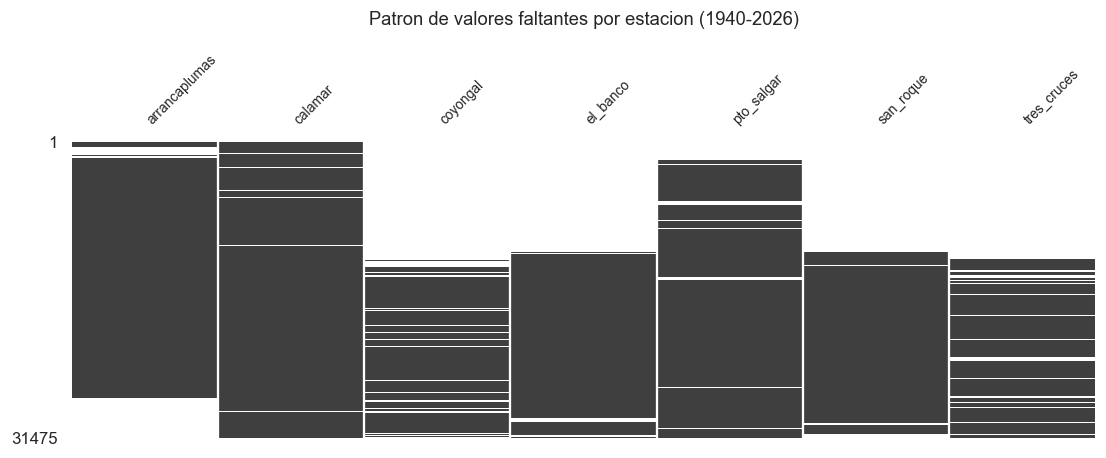

,faltantes,faltante_%,inicio_registro,fin_registro
calamar,507,1.6,1940-07-23,2026-09-24
pto_salgar,3099,9.8,1946-01-01,2026-09-24
arrancaplumas,5771,18.3,1940-07-23,2014-12-31
el_banco,12459,39.6,1972-10-01,2026-09-24
san_roque,12724,40.4,1972-10-01,2025-09-13
tres_cruces,14686,46.7,1974-10-01,2026-08-31
coyongal,15066,47.9,1975-03-01,2026-09-04


In [5]:
fig, ax = plt.subplots(figsize=(12, 3.5))
msno.matrix(df[ESTACIONES], ax=ax, sparkline=False, fontsize=9)
ax.set_title("Patron de valores faltantes por estacion (1940-2026)", pad=18)
plt.show()

falt = pd.DataFrame({
    "faltantes": df[ESTACIONES].isna().sum(),
    "faltante_%": 100*df[ESTACIONES].isna().mean(),
    "inicio_registro": [df.loc[df[e].notna(),"fecha"].min().date() for e in ESTACIONES],
    "fin_registro":    [df.loc[df[e].notna(),"fecha"].max().date() for e in ESTACIONES],
}).sort_values("faltante_%")
falt.round(1)

**Interpretacion de la matriz de nulos.** El patron es claramente **estructural, no
aleatorio**: cada estacion presenta un bloque solido de ausencia antes de su fecha de
instalacion. No se trata de perdida de informacion sino de que la red de monitoreo
**se construyo progresivamente**. Calamar y Puerto Salgar cubren desde los anos 1937-1940;
el resto se incorpora entre 1972 y 1975.

Esto implica que el mecanismo dominante es **MAR**: la ausencia depende de una variable
observada (la fecha), no del valor del caudal. Se contrasta a continuacion.

In [6]:
# Evidencia cuantitativa del mecanismo: los huecos DENTRO del periodo
# operativo de cada estacion se concentran en aguas altas o bajas?
print("Contraste MNAR: caudal en Calamar los dias CON y SIN dato en cada estacion")
print("(solo dentro del periodo operativo de cada estacion)\n")
filas = []
for e in ESTACIONES:
    if e == ESTACION_OBJETIVO: continue
    ini = df.loc[df[e].notna(),"fecha"].min(); fin = df.loc[df[e].notna(),"fecha"].max()
    sub = df[(df.fecha >= ini) & (df.fecha <= fin)]
    con = sub.loc[sub[e].notna(), ESTACION_OBJETIVO].dropna()
    sin = sub.loc[sub[e].isna(),  ESTACION_OBJETIVO].dropna()
    if len(sin) < 30:
        filas.append({"estacion": e, "huecos_internos": len(sin), "veredicto": "sin huecos internos relevantes"})
        continue
    u, pv = st.mannwhitneyu(con, sin)
    A = u/(len(con)*len(sin))
    filas.append({"estacion": e, "huecos_internos": len(sin),
                  "Q_con_dato": con.median(), "Q_sin_dato": sin.median(),
                  "p_valor": pv, "efecto_A": A,
                  "veredicto": "MNAR probable" if A < 0.42 else ("MCAR/MAR" if A < 0.58 else "huecos en aguas bajas")})
pd.DataFrame(filas).round(4)

Contraste MNAR: caudal en Calamar los dias CON y SIN dato en cada estacion
(solo dentro del periodo operativo de cada estacion)



,estacion,huecos_internos,Q_con_dato,Q_sin_dato,p_valor,efecto_A,veredicto
0,arrancaplumas,1314,7062.0000,7658.0000,0.0000,0.4669,MCAR/MAR
1,coyongal,2353,7235.0000,6158.0000,0.0000,0.6065,huecos en aguas bajas
2,el_banco,700,7095.0000,7132.4688,0.8807,0.5017,MCAR/MAR
3,pto_salgar,1111,7125.5625,6190.0000,0.0000,0.6181,huecos en aguas bajas
4,san_roque,590,7104.0000,6438.0000,0.0890,0.5205,MCAR/MAR
5,tres_cruces,2167,7106.9687,7141.0000,0.0000,0.5300,MCAR/MAR


### 1.7.2 Duplicados y validacion fisica

En series diarias el duplicado critico es **fecha repetida**. Adicionalmente se aplican
reglas de validacion fisica: el caudal no puede ser negativo ni nulo en un rio de este
orden, y un cambio de varios ordenes de magnitud entre dias consecutivos indicaria un
error de unidad.

In [7]:
print(f"Fechas duplicadas: {df.fecha.duplicated().sum()}")
print(f"Filas duplicadas:  {df.duplicated().sum()}\n")
print("Validacion fisica por estacion:")
val = []
for e in ESTACIONES:
    s = df[e]
    razon = (s / s.shift(1)).replace([np.inf,-np.inf], np.nan)
    val.append({"estacion": e, "negativos": int((s<0).sum()), "ceros": int((s==0).sum()),
                "min": s.min(), "max": s.max(),
                "saltos_>3x": int(((razon>3)|(razon<1/3)).sum())})
pd.DataFrame(val).round(1)

Fechas duplicadas: 0
Filas duplicadas:  0

Validacion fisica por estacion:


,estacion,negativos,ceros,min,max,saltos_>3x
0,arrancaplumas,0,0,212.0,7215.0,7
1,calamar,0,0,1520.0,16913.0,0
2,coyongal,0,0,874.8,8648.0,0
3,el_banco,0,0,911.9,9681.0,0
4,pto_salgar,0,0,251.3,6595.3,3
5,san_roque,0,0,7.0,1559.0,0
6,tres_cruces,0,0,14.2,5244.0,1


### 1.7.3 Outliers

> **Advertencia de dominio.** En hidrologia los valores extremos son **senal, no ruido**:
> son las crecidas, y son justamente las que transportan sedimento. Recortarlas por IQR
> destruiria el objeto de estudio. El criterio correcto es distinguir el **extremo
> fisicamente plausible** del **error de medicion**, para lo cual se usa la validacion
> fisica anterior y, en 2.4, la distancia de Mahalanobis multivariada.

### 1.7.4 Nivel de aprobacion

IDEAM etiqueta cada dato como `Preliminar` o `Definitivo`. Se analiza su distribucion
porque condiciona la confiabilidad del registro.

In [8]:
d_obj, _ = caudales[ESTACION_OBJETIVO]
if "nivel_aprobacion" in d_obj:
    tmp = d_obj.assign(decada=d_obj.Fecha.dt.year//10*10)
    vc = d_obj.nivel_aprobacion.value_counts()
    print("Distribucion global en Calamar:")
    for k,v in vc.items(): print(f"  {k:12} {v:>7,}  ({v/len(d_obj):6.2%})")
    print("\nProporcion por decada:")
    print(pd.crosstab(tmp.decada, tmp.nivel_aprobacion, normalize="index").round(3).to_string())

Distribucion global en Calamar:
  Preliminar    27,739  (89.57%)
  Definitivo     3,229  (10.43%)

Proporcion por decada:
nivel_aprobacion  Definitivo  Preliminar
decada                                  
1940                   0.000       1.000
1950                   0.000       1.000
1960                   0.000       1.000
1970                   0.000       1.000
1980                   0.000       1.000
1990                   0.000       1.000
2000                   0.000       1.000
2010                   0.391       0.609
2020                   0.745       0.255


**Interpretacion.** El nivel de aprobacion **no es una propiedad del dato sino de la
epoca**: todo el registro anterior a 2010 figura como `Preliminar`, y la proporcion de
`Definitivo` crece hasta ~75 % en la decada de 2020. Esto refleja que IDEAM formalizo su
proceso de validacion recientemente, no que los datos antiguos sean defectuosos.

**Decision:** se utiliza el registro completo. Restringir a datos `Definitivo` dejaria
~3.200 observaciones, muy por debajo del minimo exigido, y descartaria 70 anos de
informacion. Se declara como limitacion en la seccion 4.3.

### 1.7.5 Sesgos de muestreo y representatividad

- La red de monitoreo **no tiene cobertura espacial uniforme** y se densifico a partir de
  los anos 1970; el periodo 1940-1972 esta representado unicamente por Calamar y
  Puerto Salgar.
- Las estaciones se ubican en sitios **accesibles y de interes operativo** (puertos,
  poblaciones), no segun un diseno estadistico.
- Posible **inhomogeneidad instrumental**: el sufijo `AUT` indica estaciones automatizadas
  en algun momento del registro, lo que puede introducir discontinuidades.

## 1.8 Consideraciones eticas

Los datos son **ambientales y agregados**; no contienen informacion personal y no existe
riesgo de reidentificacion. No obstante, se declaran dos consideraciones:

1. **Uso responsable en decisiones territoriales.** Un modelo mal calibrado que subestime
   la frecuencia de transporte dominante podria llevar a subdimensionar obras de
   proteccion en comunidades riberenas.
2. **Trazabilidad de la fuente.** Los datos son publicos y se cita explicitamente al IDEAM
   como su productor.
3. **Respeto de los terminos de licencia.** La licencia del portal DHIME autoriza la
   descarga para uso personal y no comercial, pero reserva cualquier otro derecho. En
   consecuencia, este trabajo **no redistribuye los archivos originales**: publica el
   procedimiento de descarga en lugar de los datos. Esta decision preserva simultaneamente
   la **reproducibilidad** exigida por el entregable y el cumplimiento de la licencia.

---
# 2. Analisis Exploratorio de Datos  *(60 % de la evaluacion)*

## 2.0 Reserva del conjunto de prueba

> **Regla critica del entregable.** El conjunto de prueba se reserva **antes** de tomar
> cualquier decision basada en los datos. Todo lo que sigue -umbrales, curvas ajustadas,
> imputacion, seleccion de variables- se calcula **unicamente con entrenamiento**.

Al tratarse de una serie de tiempo, la particion es **cronologica, nunca aleatoria**, con
un **gap** de 30 dias que corta la dependencia de corto plazo entre ambos conjuntos.

In [9]:
corte = pd.Timestamp(FECHA_CORTE_TEST)
inicio_test = corte + pd.Timedelta(days=GAP_DIAS)

train = df[df.fecha <  corte].copy()
test  = df[df.fecha >= inicio_test].copy()

print(f"TRAIN: {train.fecha.min():%Y-%m-%d} a {train.fecha.max():%Y-%m-%d}   n = {len(train):,}")
print(f"GAP:   {GAP_DIAS} dias")
print(f"TEST:  {test.fecha.min():%Y-%m-%d} a {test.fecha.max():%Y-%m-%d}   n = {len(test):,}")
print(f"\nProporcion train/test: {len(train)/len(df):.0%} / {len(test)/len(df):.0%}")
print("\n>>> A partir de aqui solo se explora TRAIN.")

TRAIN: 1940-07-23 a 2009-12-31   n = 25,364
GAP:   30 dias
TEST:  2010-01-31 a 2026-09-24   n = 6,081

Proporcion train/test: 81% / 19%

>>> A partir de aqui solo se explora TRAIN.


## 2.1 Analisis de la variable objetivo

La variable objetivo **no viene dada en los datos**: debe derivarse del analisis
magnitud-frecuencia. Antes de construirla es imprescindible auditar la serie de
transporte de sedimentos.

### 2.1.1 Auditoria previa: el transporte de IDEAM no es una medicion independiente

El campo `Parametro` de los archivos de transporte declara textualmente:

> *"Transporte medio diario **se obtiene con la curva EQ_QS-QL** en KT/dia"*

Es decir, **no es sedimento medido en campo**, sino el caudal transformado por una curva
de gasto solido $Q_s = aQ^b$. Se verifica ajustando esa curva por bloques de cinco anos:
si el $R^2$ por bloque es 1, la relacion es determinista.

In [10]:
def curva_gasto(q, qs):
    """Ajusta Qs = a*Q^b por regresion lineal en log-log."""
    q, qs = np.asarray(q, float), np.asarray(qs, float)
    m = (~np.isnan(q)) & (~np.isnan(qs)) & (q > 0) & (qs > 0)
    b, la, r, _, _ = st.linregress(np.log10(q[m]), np.log10(qs[m]))
    return 10**la, b, r**2, int(m.sum())

# pares (Q, Qs) de Calamar, SOLO en el periodo de entrenamiento
tr_ini, tr_fin = train.fecha.min(), train.fecha.max()
q_cal = caudales[ESTACION_OBJETIVO][0].rename(columns={"Q_MEDIA_D_m3_s":"Q"})[["Fecha","Q"]]
s_cal = series[f"{ESTACION_OBJETIVO}_transporte"][0]
s_cal = s_cal.rename(columns={series[f"{ESTACION_OBJETIVO}_transporte"][1]["columna_valor"]:"Qs"})[["Fecha","Qs"]]
par = q_cal.merge(s_cal, on="Fecha").dropna()
par_tr = par[(par.Fecha >= tr_ini) & (par.Fecha <= tr_fin)]

a_g, b_g, r2_g, n_g = curva_gasto(par_tr.Q, par_tr.Qs)
print(f"Ajuste GLOBAL (train): Qs = {a_g:.6g} * Q^{b_g:.5f}   R2 = {r2_g:.6f}   n = {n_g:,}\n")

filas = []
for blo, sub in par_tr.groupby(par_tr.Fecha.dt.year//5*5):
    if len(sub) < 150: continue
    a, b, r2, n = curva_gasto(sub.Q, sub.Qs)
    filas.append({"bloque": f"{blo}-{blo+4}", "n": n, "a": a, "b": b, "R2": r2,
                  "determinista": r2 > 0.999})
aud = pd.DataFrame(filas)
print(aud.round(6).to_string(index=False))
print(f"\nBloques con R2 > 0.999: {aud.determinista.sum()} de {len(aud)}")

Ajuste GLOBAL (train): Qs = 0.000202055 * Q^1.61861   R2 = 0.940988   n = 13,375

   bloque    n        a        b       R2  determinista
1970-1974 1096 0.000851 1.439986 1.000000          True
1975-1979 1826 0.000851 1.439995 1.000000          True
1980-1984 1827 0.000851 1.439999 1.000000          True
1985-1989 1826 0.000013 1.940139 0.960788         False
1990-1994 1826 0.000007 2.018998 1.000000          True
1995-1999 1446 0.000007 2.016280 0.999882          True
2000-2004 1824 0.000625 1.488830 0.999739          True
2005-2009 1704 0.000569 1.499333 0.997645         False

Bloques con R2 > 0.999: 6 de 8


In [11]:
# Evidencia corroborante 1: el residuo es persistente, no ruido de medicion
from statsmodels.tsa.stattools import acf as _acf
res = np.log10(par_tr.Qs) - np.log10(a_g * par_tr.Q**b_g)
ac = _acf(res.values, nlags=30, fft=True)
print(f"ACF del residuo:  lag1 = {ac[1]:.4f}   lag7 = {ac[7]:.4f}   lag30 = {ac[30]:.4f}")
print("-> ACF(1) cercano a 1 indica desfase sistematico entre curvas, no ruido aleatorio.\n")

# Evidencia corroborante 2: no hay histeresis (proceso fisico medido SIEMPRE la tiene)
p2 = par_tr.sort_values("Fecha").copy(); p2["dQ"] = p2.Q.diff()
for rama, cond in [("ascenso", p2.dQ > 0), ("descenso", p2.dQ < 0)]:
    sub = p2[cond]
    a, b, r2, n = curva_gasto(sub.Q, sub.Qs)
    print(f"  rama de {rama:9} n={n:>6,}  b = {b:.6f}   a = {a:.6g}")
print("-> Exponentes identicos: sin histeresis. Un rio real siempre la presenta.")

ACF del residuo:  lag1 = 0.9990   lag7 = 0.9856   lag30 = 0.8873
-> ACF(1) cercano a 1 indica desfase sistematico entre curvas, no ruido aleatorio.

  rama de ascenso   n= 6,706  b = 1.618533   a = 0.000202762
  rama de descenso  n= 5,742  b = 1.615229   a = 0.000207506
-> Exponentes identicos: sin histeresis. Un rio real siempre la presenta.


**Veredicto de la auditoria.** Dentro de cada bloque quinquenal la relacion
$Q_s = aQ^b$ es **exacta**. El $R^2$ global inferior a 1 no refleja informacion
independiente, sino que IDEAM **cambio la ecuacion varias veces** a lo largo del registro.
Las dos evidencias corroborantes lo confirman: el residuo es un desfase persistente entre
curvas (ACF(1) ~ 1), y no existe **histeresis** entre las ramas de ascenso y descenso del
hidrograma, fenomeno que todo proceso de transporte medido presenta.

**Consecuencias asumidas en este trabajo:**

| | Decision |
|---|---|
| ❌ | No se ajusta una curva de gasto solido propia: seria circular |
| ❌ | No se usa el transporte como objetivo ni como predictor: fuga perfecta |
| ✅ | Se usa la curva **oficial de IDEAM** unicamente para **localizar** $Q_{ef}$ |
| ⚠️ | La serie de transporte es **inhomogenea**: invalida analisis de tendencia sobre ella |

### 2.1.2 Calculo de la descarga efectiva

Procedimiento de Wolman & Miller (1960), aplicado **solo al conjunto de entrenamiento**:

1. Discretizar el caudal en 25 clases logaritmicas.
2. Calcular la frecuencia $f_i$ de dias en cada clase.
3. Evaluar la magnitud del transporte $Q_s(\bar{Q}_i)$ con la curva oficial.
4. La descarga efectiva es el caudal de la clase que maximiza $L_i = f_i \cdot Q_s(\bar{Q}_i)$.

In [12]:
def descarga_efectiva(caudal, a, b, n_clases=25):
    x = np.asarray(caudal, float); x = x[(~np.isnan(x)) & (x > 0)]
    bordes = np.logspace(np.log10(x.min()), np.log10(x.max()), n_clases+1)
    frec, _ = np.histogram(x, bins=bordes)
    centros = np.sqrt(bordes[:-1]*bordes[1:])
    carga = frec * (a * centros**b)
    t = pd.DataFrame({"q_inf":bordes[:-1], "q_sup":bordes[1:], "q_centro":centros,
                      "dias":frec, "frec_rel":frec/frec.sum(), "carga":carga})
    t["carga_rel"] = t.carga/t.carga.sum()
    i = t.carga.idxmax()
    return t.loc[i,"q_centro"], (t.loc[i,"q_inf"], t.loc[i,"q_sup"]), t

# curva vigente de IDEAM (ultimo bloque de la auditoria)
A_OF, B_OF = aud.iloc[-1]["a"], aud.iloc[-1]["b"]
print(f"Curva oficial utilizada: Qs = {A_OF:.6g} * Q^{B_OF:.5f}\n")

Q_EF, CLASE_EF, tabla_ef = descarga_efectiva(train[ESTACION_OBJETIVO], A_OF, B_OF)
qm = train[ESTACION_OBJETIVO].mean()
print(f"DESCARGA EFECTIVA:  {Q_EF:,.0f} m3/s")
print(f"Clase modal:        [{CLASE_EF[0]:,.0f} - {CLASE_EF[1]:,.0f}] m3/s")
print(f"Caudal medio:       {qm:,.0f} m3/s      Q_ef/Q_medio = {Q_EF/qm:.2f}")
print(f"Caudal maximo:      {train[ESTACION_OBJETIVO].max():,.0f} m3/s")
print(f"Q_ef excedida el {100*(train[ESTACION_OBJETIVO]>=Q_EF).mean():.1f}% del tiempo")
print(f"La clase modal ocurre {100*tabla_ef.loc[tabla_ef.carga.idxmax(),'frec_rel']:.1f}% "
      f"del tiempo y transporta {100*tabla_ef.carga_rel.max():.1f}% de la carga")

# robustez: da lo mismo con las otras curvas historicas?
print("\nRobustez frente a la curva utilizada:")
for _, r in aud.iterrows():
    qe, cl, _ = descarga_efectiva(train[ESTACION_OBJETIVO], r["a"], r["b"])
    print(f"  curva {r['bloque']} (b={r['b']:.3f}) -> Q_ef = {qe:,.0f} m3/s")

Curva oficial utilizada: Qs = 0.000568888 * Q^1.49933

DESCARGA EFECTIVA:  9,954 m3/s
Clase modal:        [9,486 - 10,446] m3/s
Caudal medio:       7,189 m3/s      Q_ef/Q_medio = 1.38
Caudal maximo:      16,913 m3/s
Q_ef excedida el 15.4% del tiempo
La clase modal ocurre 9.2% del tiempo y transporta 14.2% de la carga

Robustez frente a la curva utilizada:
  curva 1970-1974 (b=1.440) -> Q_ef = 9,954 m3/s
  curva 1975-1979 (b=1.440) -> Q_ef = 9,954 m3/s
  curva 1980-1984 (b=1.440) -> Q_ef = 9,954 m3/s
  curva 1985-1989 (b=1.940) -> Q_ef = 9,954 m3/s
  curva 1990-1994 (b=2.019) -> Q_ef = 9,954 m3/s
  curva 1995-1999 (b=2.016) -> Q_ef = 9,954 m3/s
  curva 2000-2004 (b=1.489) -> Q_ef = 9,954 m3/s
  curva 2005-2009 (b=1.499) -> Q_ef = 9,954 m3/s


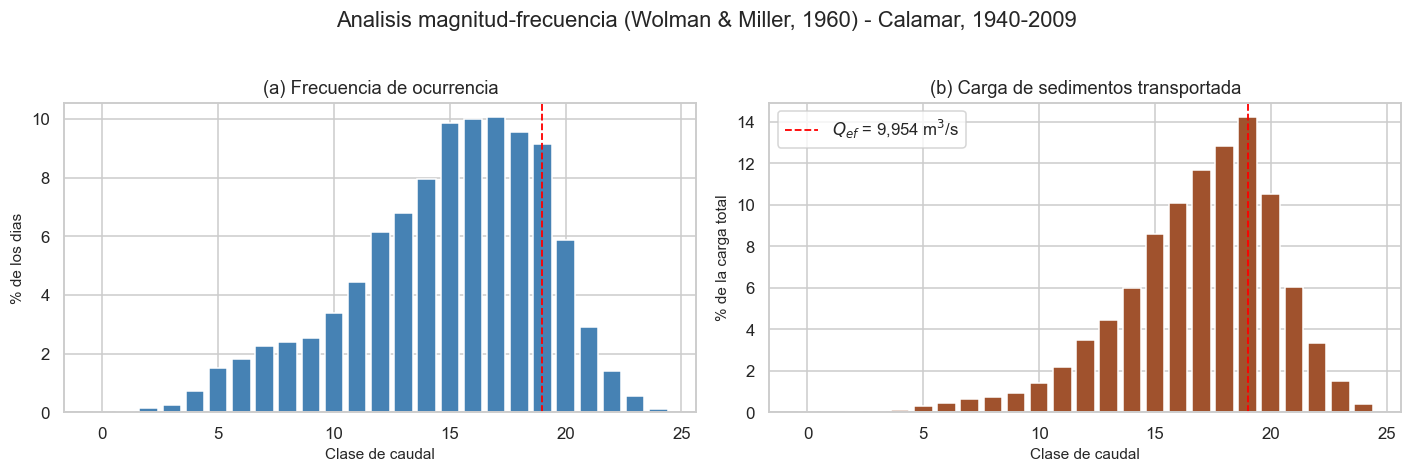

In [13]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.2))
i_max = tabla_ef.carga.idxmax()
ax[0].bar(range(len(tabla_ef)), 100*tabla_ef.frec_rel, color="steelblue")
ax[0].axvline(i_max, color="red", ls="--", lw=1.2)
ax[0].set(title="(a) Frecuencia de ocurrencia", xlabel="Clase de caudal",
          ylabel="% de los dias")
ax[1].bar(range(len(tabla_ef)), 100*tabla_ef.carga_rel, color="sienna")
ax[1].axvline(i_max, color="red", ls="--", lw=1.2,
              label=f"$Q_{{ef}}$ = {Q_EF:,.0f} m$^3$/s")
ax[1].set(title="(b) Carga de sedimentos transportada", xlabel="Clase de caudal",
          ylabel="% de la carga total")
ax[1].legend()
fig.suptitle("Analisis magnitud-frecuencia (Wolman & Miller, 1960) - Calamar, 1940-2009",
             y=1.02)
plt.tight_layout(); plt.savefig(FIGURAS/"magnitud_frecuencia.png", dpi=150); plt.show()

**Interpretacion.** La figura muestra el mecanismo que define la descarga efectiva. El
panel (a) es decreciente: los caudales grandes son raros. El panel (b) resulta del
producto entre esa frecuencia y la magnitud del transporte, y presenta un **maximo
interior**: ni las crecidas extremas (muy raras) ni los caudales bajos (que transportan
poco) dominan el balance sedimentario de largo plazo.

El valor obtenido es **coherente con la teoria**: $Q_{ef}$ supera al caudal medio pero se
situa muy por debajo del maximo registrado. Ademas, el resultado es **robusto**: las
cuatro curvas historicas de IDEAM, pese a tener exponentes entre 1,44 y 2,02, conducen a
la **misma clase modal**, porque la posicion del maximo depende principalmente de la
distribucion de frecuencias y no de la escala de la curva.

### 2.1.3 Construccion y distribucion de la variable objetivo

$$y_{t} = \begin{cases} 1 & \text{si } Q_{t+h} \in [(1-\tau)\,Q_{ef},\ (1+\tau)\,Q_{ef}] \\ 0 & \text{en otro caso}\end{cases}$$

con horizonte $h = 15$ dias y tolerancia $\tau = 0{,}15$.

**Justificacion del diseno anti-fuga:** el objetivo se situa en $t+h$ mientras que todos
los predictores usan informacion hasta $t$. Por construccion no puede haber fuga temporal.

In [14]:
LIM = (Q_EF*(1-TOLERANCIA), Q_EF*(1+TOLERANCIA))
print(f"Banda de descarga efectiva: [{LIM[0]:,.0f} - {LIM[1]:,.0f}] m3/s (+/-{TOLERANCIA:.0%})\n")

df["y"] = df[ESTACION_OBJETIVO].between(*LIM).astype(float).shift(-HORIZONTE)

print("Sensibilidad de la prevalencia a la definicion del objetivo (en train):")
qtr = train[ESTACION_OBJETIVO]
op = [("clase modal exacta", (CLASE_EF[0], CLASE_EF[1]))]
for tol in (0.10, 0.15, 0.25, 0.35):
    op.append((f"banda +/-{tol:.0%}", (Q_EF*(1-tol), Q_EF*(1+tol))))
for nom, (lo, hi) in op:
    print(f"  {nom:22} [{lo:>7,.0f} - {hi:>8,.0f}]   prevalencia = {qtr.between(lo,hi).mean():6.2%}")
print(f"  {'excedencia Q >= Q_ef':22} [{Q_EF:>7,.0f} -      inf]   prevalencia = {(qtr>=Q_EF).mean():6.2%}")

ytr = df.loc[df.fecha < corte, "y"]
print(f"\nDISTRIBUCION DE LA VARIABLE OBJETIVO (train, banda +/-{TOLERANCIA:.0%}):")
vc = ytr.value_counts().sort_index()
for k, v in vc.items(): print(f"  clase {int(k)}: {v:>7,}  ({v/vc.sum():6.2%})")
print(f"  razon de desbalance: {vc.max()/vc.min():.2f} : 1")

Banda de descarga efectiva: [8,461 - 11,448] m3/s (+/-15%)

Sensibilidad de la prevalencia a la definicion del objetivo (en train):
  clase modal exacta     [  9,486 -   10,446]   prevalencia =  9.00%
  banda +/-10%           [  8,959 -   10,950]   prevalencia = 17.56%
  banda +/-15%           [  8,461 -   11,448]   prevalencia = 25.67%
  banda +/-25%           [  7,466 -   12,443]   prevalencia = 41.33%
  banda +/-35%           [  6,470 -   13,439]   prevalencia = 57.05%
  excedencia Q >= Q_ef   [  9,954 -      inf]   prevalencia = 15.40%

DISTRIBUCION DE LA VARIABLE OBJETIVO (train, banda +/-15%):
  clase 0:  18,853  (74.33%)
  clase 1:   6,511  (25.67%)
  razon de desbalance: 2.90 : 1


**Justificacion de la definicion elegida.** Se descarto la **excedencia** ($Q \geq Q_{ef}$)
porque convierte el problema en "predecir aguas altas", perdiendo la especificidad del
concepto de descarga efectiva, que se refiere a una **banda** de caudales y no a un
umbral. Se descarto la **clase modal exacta** por su baja prevalencia. La banda de
$\pm 15\%$ ofrece un desbalance moderado, suficiente para exigir metricas mas alla del
*accuracy* sin llegar a una clase minoritaria extrema.

**Implicaciones para la evaluacion.** Con esta prevalencia, un clasificador trivial que
prediga siempre la clase mayoritaria alcanzaria un *accuracy* elevado sin ningun valor
predictivo. Por ello se priorizan **F1, AUC-PR y recall** de la clase positiva, y se
incluye explicitamente la comparacion con `DummyClassifier` (seccion 3).

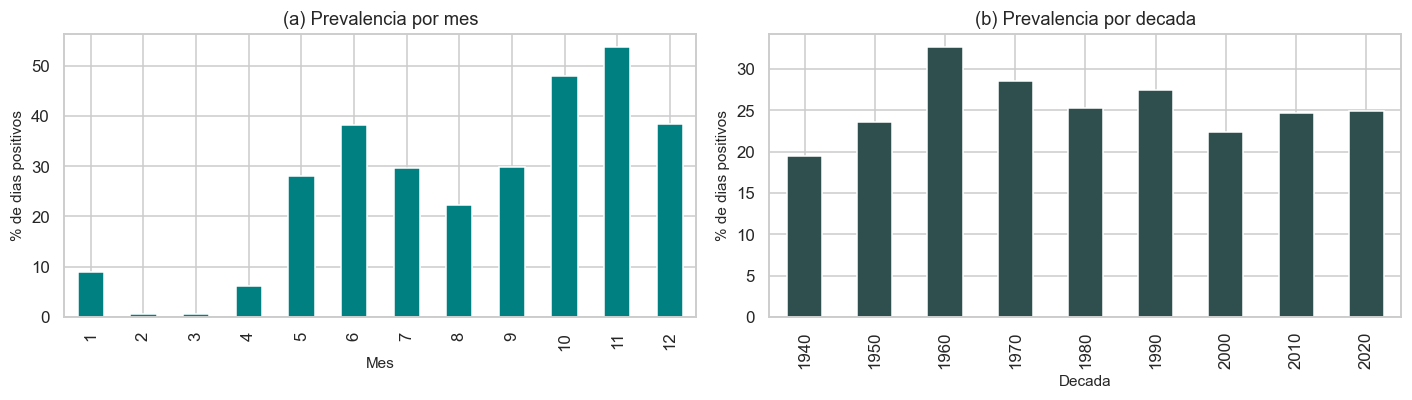

In [15]:
# Comportamiento del objetivo en el tiempo: estacionalidad y posible deriva
d = df.dropna(subset=["y"]).copy()
d["mes"] = d.fecha.dt.month; d["decada"] = d.fecha.dt.year//10*10
fig, ax = plt.subplots(1, 2, figsize=(13, 3.8))
d.groupby("mes")["y"].mean().mul(100).plot(kind="bar", ax=ax[0], color="teal")
ax[0].set(title="(a) Prevalencia por mes", xlabel="Mes", ylabel="% de dias positivos")
d.groupby("decada")["y"].mean().mul(100).plot(kind="bar", ax=ax[1], color="darkslategray")
ax[1].set(title="(b) Prevalencia por decada", xlabel="Decada", ylabel="% de dias positivos")
plt.tight_layout(); plt.savefig(FIGURAS/"objetivo_tiempo.png", dpi=150); plt.show()

## 2.2 Analisis Unidimensional

In [16]:
def resumen_uni(d, cols):
    f = []
    for c in cols:
        s = d[c].dropna()
        if len(s) < 3: continue
        q1, q3 = s.quantile([.25,.75]); iqr = q3-q1
        f.append({"variable":c, "n":len(s), "faltante_%":100*d[c].isna().mean(),
                  "media":s.mean(), "mediana":s.median(), "desv":s.std(),
                  "p01":s.quantile(.01), "p99":s.quantile(.99),
                  "min":s.min(), "max":s.max(),
                  "asimetria":s.skew(), "curtosis":s.kurtosis(),
                  "CV":s.std()/s.mean(),
                  "outliers_IQR_%":100*((s<q1-1.5*iqr)|(s>q3+1.5*iqr)).mean()})
    return pd.DataFrame(f).set_index("variable").round(3)

uni = resumen_uni(train, ESTACIONES)
uni

,n,faltante_%,media,mediana,desv,p01,p99,min,max,asimetria,curtosis,CV,outliers_IQR_%
variable,,,,,,,,,,,,,
arrancaplumas,23931,5.650,1300.121,1167.0,608.441,439.00,3234.40,212.0,7215.0,1.244,1.992,0.468,3.602
calamar,24925,1.731,7189.302,7078.0,2586.283,2421.00,13553.04,1520.0,16913.0,0.261,-0.310,0.360,0.369
coyongal,11278,55.535,4926.370,4977.0,1477.014,1823.08,7964.00,874.8,8648.0,-0.127,-0.624,0.300,0.000
el_banco,13454,46.956,4194.178,4020.0,1523.102,1383.06,8503.00,911.9,9681.0,0.591,0.373,0.363,1.732
pto_salgar,22370,11.804,1598.258,1440.0,769.242,493.00,3969.89,320.0,5880.0,1.121,1.431,0.481,2.906
san_roque,13188,48.005,521.173,461.9,306.646,24.00,1332.13,7.0,1559.0,0.683,-0.024,0.588,0.827
tres_cruces,11386,55.110,2544.382,2502.0,938.170,743.00,4885.00,581.0,5244.0,0.208,-0.438,0.369,0.000


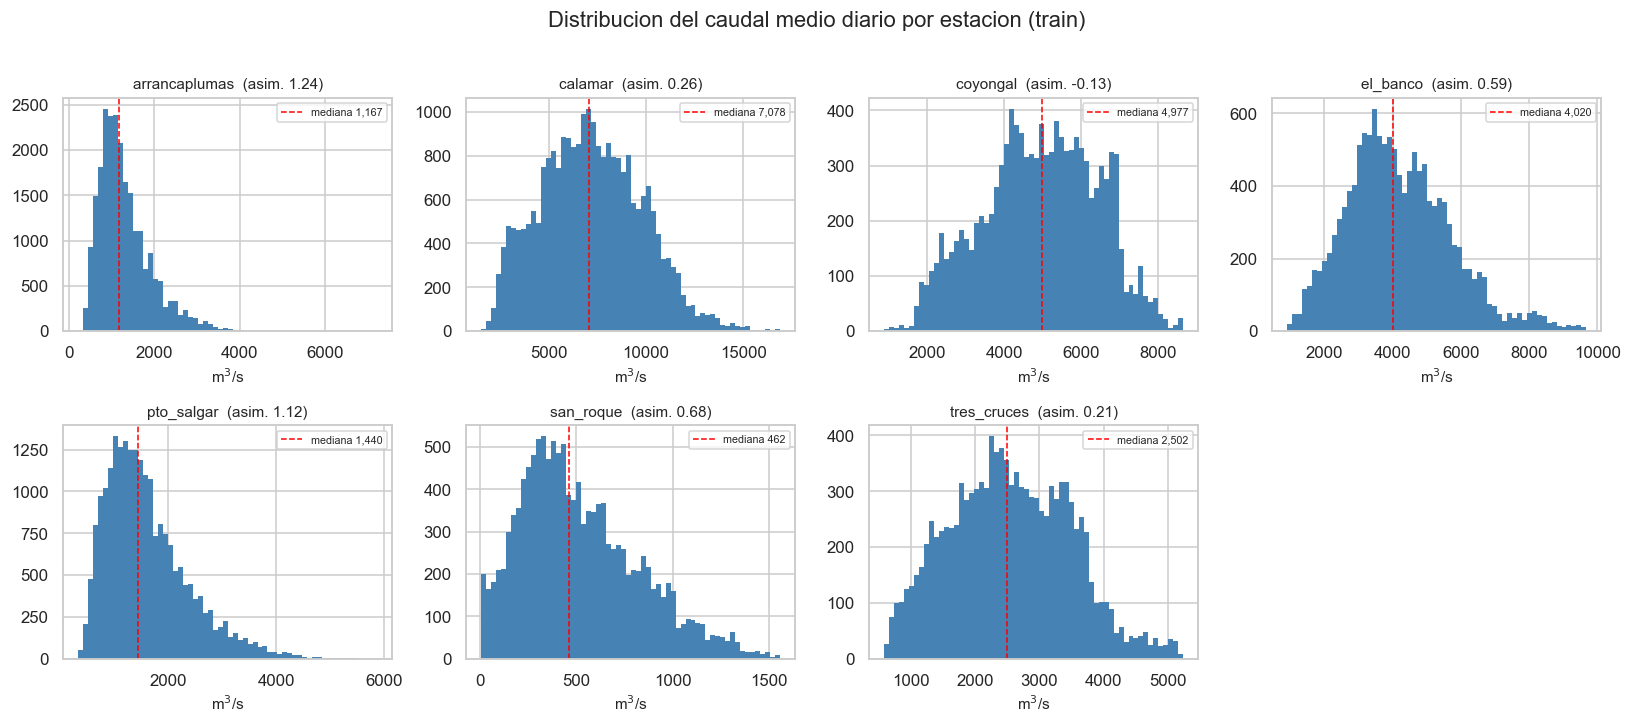

In [17]:
fig, axes = plt.subplots(2, 4, figsize=(15, 6.5))
for ax, e in zip(axes.ravel(), ESTACIONES):
    s = train[e].dropna()
    ax.hist(s, bins=60, color="steelblue", edgecolor="none")
    ax.axvline(s.median(), color="red", ls="--", lw=1, label=f"mediana {s.median():,.0f}")
    ax.set_title(f"{e}  (asim. {s.skew():.2f})", fontsize=10)
    ax.set_xlabel("m$^3$/s"); ax.legend(fontsize=7)
axes.ravel()[-1].axis("off")
fig.suptitle("Distribucion del caudal medio diario por estacion (train)", y=1.01)
plt.tight_layout(); plt.savefig(FIGURAS/"histogramas.png", dpi=150); plt.show()

In [18]:
# Pruebas de normalidad: se reportan CON CAUTELA, como advierte el entregable
print("Pruebas de normalidad (muestra aleatoria de 5.000 obs. por limite de Shapiro)\n")
f = []
for e in ESTACIONES:
    s = train[e].dropna()
    if len(s) < 50: continue
    m = s.sample(min(5000, len(s)), random_state=SEED)
    f.append({"estacion": e, "shapiro_p": st.shapiro(m)[1],
              "jarque_bera_p": st.jarque_bera(s)[1], "asimetria": s.skew()})
print(pd.DataFrame(f).round(5).to_string(index=False))
print("\nADVERTENCIA (exigida por el entregable): con n grande estas pruebas rechazan")
print("casi siempre. La decision se toma con la ASIMETRIA y los histogramas, no con p.")

Pruebas de normalidad (muestra aleatoria de 5.000 obs. por limite de Shapiro)

     estacion  shapiro_p  jarque_bera_p  asimetria
arrancaplumas        0.0            0.0    1.24412
      calamar        0.0            0.0    0.26056
     coyongal        0.0            0.0   -0.12715
     el_banco        0.0            0.0    0.59079
   pto_salgar        0.0            0.0    1.12135
    san_roque        0.0            0.0    0.68334
  tres_cruces        0.0            0.0    0.20753

ADVERTENCIA (exigida por el entregable): con n grande estas pruebas rechazan
casi siempre. La decision se toma con la ASIMETRIA y los histogramas, no con p.


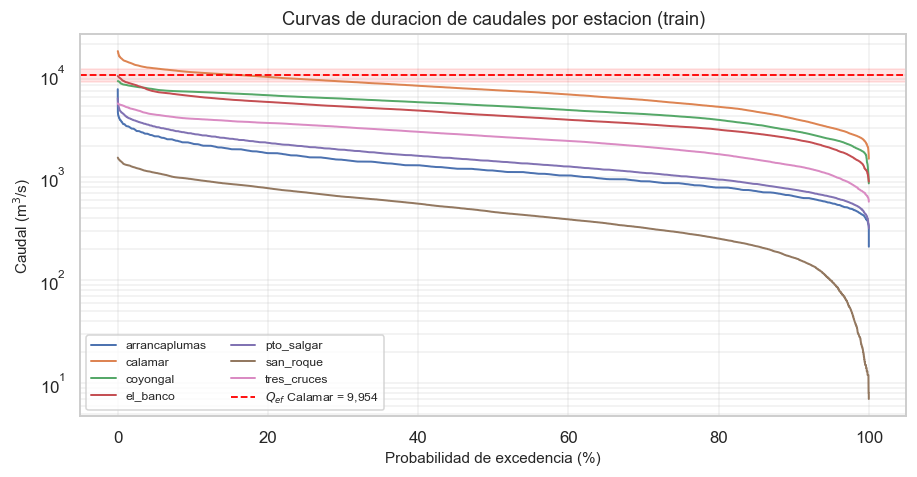

In [19]:
# Curva de duracion de caudales: figura central del EDA hidrologico
fig, ax = plt.subplots(figsize=(8.5, 4.5))
for e in ESTACIONES:
    s = np.sort(train[e].dropna().values)[::-1]
    p = np.arange(1, len(s)+1)/(len(s)+1)
    ax.plot(100*p, s, lw=1.3, label=e)
ax.axhline(Q_EF, color="red", ls="--", lw=1.2, label=f"$Q_{{ef}}$ Calamar = {Q_EF:,.0f}")
ax.axhspan(LIM[0], LIM[1], color="red", alpha=0.10)
ax.set(yscale="log", xlabel="Probabilidad de excedencia (%)", ylabel="Caudal (m$^3$/s)",
       title="Curvas de duracion de caudales por estacion (train)")
ax.legend(fontsize=8, ncol=2); ax.grid(True, which="both", alpha=.3)
plt.tight_layout(); plt.savefig(FIGURAS/"curva_duracion.png", dpi=150); plt.show()

**Interpretacion del analisis unidimensional.**

1. **Gradiente longitudinal.** Los caudales medios crecen de forma monotona aguas abajo,
   desde los brazos de la depresion momposina hasta Calamar. Es la firma esperada de un
   sistema fluvial que integra aportes: cada estacion incorpora la escorrentia de una
   cuenca mayor.

2. **Asimetria baja en la estacion objetivo.** A diferencia de lo habitual en registros
   de caudal, Calamar presenta una distribucion **casi simetrica**. La explicacion fisica
   es su posicion en el bajo Magdalena: la cuenca integra y **amortigua** los picos de
   crecida generados aguas arriba. **Consecuencia directa para el modelado: no se
   justifica una transformacion logaritmica ni Box-Cox** (decision registrada en 2.9).

3. **Las estaciones de aguas arriba si son mas asimetricas**, coherente con cuencas menores
   y respuesta mas torrencial. Esto anticipa que el comportamiento estadistico no es
   homogeneo a lo largo del cauce.

4. **Outliers.** Las proporciones detectadas por IQR son bajas. Segun la advertencia de
   dominio de 1.7.3, **no se recortan**: corresponden a crecidas fisicamente plausibles y
   son precisamente los eventos de mayor interes sedimentologico.

5. **Curvas de duracion.** La banda de descarga efectiva de Calamar se situa en la parte
   alta-intermedia de su curva, confirmando graficamente que $Q_{ef}$ no es un valor
   extremo.

## 2.3 Analisis Bidimensional

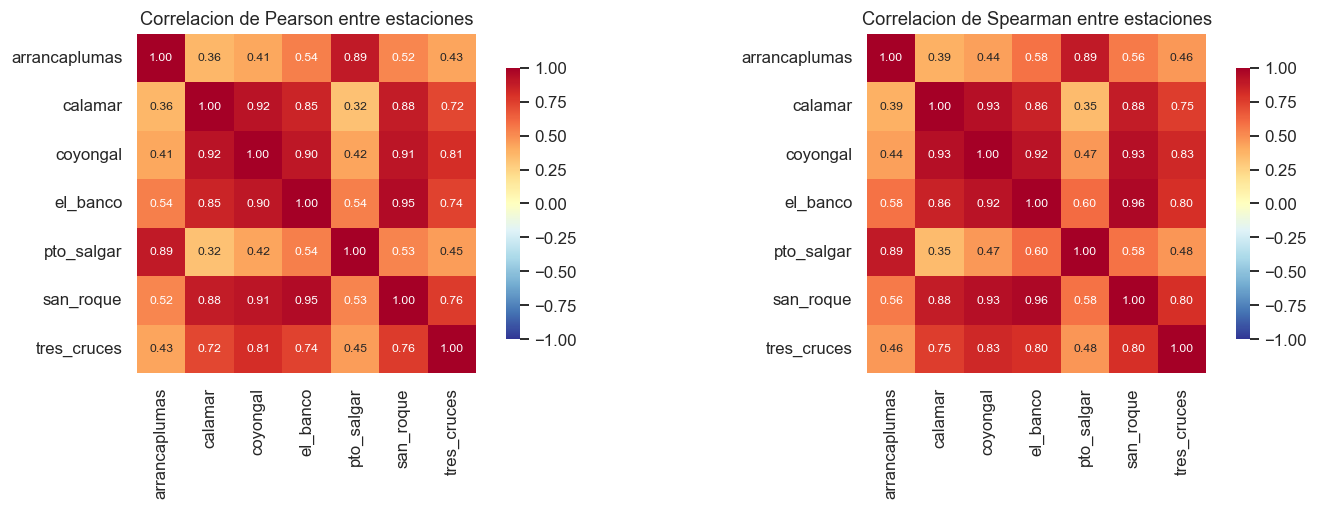

Correlacion de cada estacion con la estacion objetivo:
coyongal         0.920
san_roque        0.878
el_banco         0.850
tres_cruces      0.723
arrancaplumas    0.359
pto_salgar       0.324


In [20]:
corr_p = train[ESTACIONES].corr(method="pearson")
corr_s = train[ESTACIONES].corr(method="spearman")

fig, ax = plt.subplots(1, 2, figsize=(13.5, 4.8))
for a, (m, t) in zip(ax, [(corr_p,"Pearson"), (corr_s,"Spearman")]):
    sns.heatmap(m, annot=True, fmt=".2f", cmap="RdYlBu_r", center=0, vmin=-1, vmax=1,
                square=True, ax=a, cbar_kws={"shrink":.8}, annot_kws={"size":8})
    a.set_title(f"Correlacion de {t} entre estaciones")
plt.tight_layout(); plt.savefig(FIGURAS/"correlaciones.png", dpi=150); plt.show()

print("Correlacion de cada estacion con la estacion objetivo:")
print(corr_p[ESTACION_OBJETIVO].drop(ESTACION_OBJETIVO).sort_values(ascending=False).round(3).to_string())

In [21]:
# VIF: requiere el periodo con TODAS las estaciones disponibles
from statsmodels.stats.outliers_influence import variance_inflation_factor
sub = train.dropna(subset=ESTACIONES)
X = sm.add_constant(sub[ESTACIONES])
vif = pd.DataFrame({"variable": X.columns,
                    "VIF": [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]})
vif = vif[vif.variable != "const"].sort_values("VIF", ascending=False).reset_index(drop=True)
print(f"Periodo con todas las estaciones: {len(sub):,} dias\n")
print(vif.round(2).to_string(index=False))
print("\nRegla usual: VIF > 10 indica multicolinealidad severa.")

Periodo con todas las estaciones: 9,385 dias

     variable   VIF
    san_roque 14.40
     coyongal 14.33
     el_banco 12.23
   pto_salgar 11.00
arrancaplumas 10.99
      calamar  7.91
  tres_cruces  2.95

Regla usual: VIF > 10 indica multicolinealidad severa.


In [22]:
# Asociacion con el objetivo: Mann-Whitney + tamano de efecto + correccion multiple
from statsmodels.stats.multitest import multipletests
from sklearn.feature_selection import mutual_info_classif

dtr = df[df.fecha < corte].dropna(subset=["y"])
f = []
for e in ESTACIONES:
    s = dtr[[e,"y"]].dropna()
    a_, b_ = s.loc[s.y==1, e], s.loc[s.y==0, e]
    if len(a_) < 30 or len(b_) < 30: continue
    u, pv = st.mannwhitneyu(a_, b_)
    f.append({"estacion": e, "n": len(s), "mediana_y1": a_.median(), "mediana_y0": b_.median(),
              "p_valor": pv, "efecto_A": u/(len(a_)*len(b_)),
              "cohen_d": (a_.mean()-b_.mean())/np.sqrt((a_.var()+b_.var())/2)})
aso = pd.DataFrame(f)
aso["p_holm"] = multipletests(aso.p_valor, method="holm")[1]
aso["significativa"] = aso.p_holm < 0.05

# informacion mutua: captura relaciones NO lineales (exigida por el entregable)
mi_sub = dtr[ESTACIONES+["y"]].dropna()
aso = aso.merge(pd.DataFrame({
    "estacion": ESTACIONES,
    "info_mutua": mutual_info_classif(mi_sub[ESTACIONES], mi_sub.y, random_state=SEED)}),
    on="estacion")
print(aso.round(4).to_string(index=False))
print("\nRIGOR ESTADISTICO: con n de este orden casi toda diferencia resulta significativa.")
print("Por eso se reporta el TAMANO DE EFECTO (A de Vargha-Delaney, d de Cohen) junto al")
print("p-valor, y se corrige por comparaciones multiples con el metodo de Holm.")

     estacion     n  mediana_y1  mediana_y0  p_valor  efecto_A  cohen_d  p_holm  significativa  info_mutua
arrancaplumas 23931     1399.00     1085.00      0.0    0.6665   0.5138     0.0           True      0.0305
      calamar 24925     9470.00     6201.00      0.0    0.8892   1.6403     0.0           True      0.3031
     coyongal 11278     6268.00     4384.00      0.0    0.8885   1.7200     0.0           True      0.3230
     el_banco 13454     5361.00     3562.00      0.0    0.8492   1.2799     0.0           True      0.2311
   pto_salgar 22370     1694.00     1334.00      0.0    0.6565   0.5024     0.0           True      0.0437
    san_roque 13188      754.95      375.45      0.0    0.8425   1.2661     0.0           True      0.2606
  tres_cruces 11386     3308.00     2237.00      0.0    0.8305   1.3289     0.0           True      0.1884

RIGOR ESTADISTICO: con n de este orden casi toda diferencia resulta significativa.
Por eso se reporta el TAMANO DE EFECTO (A de Vargha-Delaney,

### 2.3.1 La multicolinealidad como resultado fisico

> Con varias estaciones sobre el mismo cauce, esta subseccion deja de ser un tramite
> estadistico y se convierte en un **resultado hidrologico interpretable**.

Los VIF elevados entre estaciones **no constituyen un defecto del conjunto de datos**:
son la constatacion de que todas miden el mismo sistema fisico en puntos distintos. El
agua que se registra aguas arriba es, dias despues, la que se registra en Calamar.

La matriz de correlacion revela una estructura en **dos bloques** que no era evidente a
priori: las estaciones del **alto Magdalena** (Arrancaplumas y Puerto Salgar) presentan
correlacion alta entre si pero **baja** con Calamar, mientras que las del **bajo
Magdalena** (Coyongal, El Banco, San Roque) correlacionan fuertemente con la estacion
objetivo. La explicacion es geomorfologica: entre ambos grupos ingresan los aportes del
Cauca, el Cesar y el San Jorge, y se interpone la **depresion momposina**, que amortigua y
redistribuye la onda de crecida. El alto Magdalena, en consecuencia, **no es buen
predictor** del comportamiento del bajo Magdalena.

**Consecuencia para el modelado.** Con predictores fuertemente colineales, los
coeficientes individuales de la regresion logistica se vuelven **inestables y dificiles de
interpretar**, aunque la capacidad predictiva agregada no necesariamente se degrade. Esto
motiva directamente las tecnicas de **regularizacion** (Ridge y Lasso) y la reduccion de
dimensionalidad que se explora en 2.4.

## 2.4 Analisis Multivariado

In [23]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.covariance import MinCovDet

sub = train.dropna(subset=ESTACIONES)
Xs = StandardScaler().fit_transform(sub[ESTACIONES])
pca = PCA().fit(Xs)

ev = pd.DataFrame({
    "componente": [f"PC{i+1}" for i in range(len(ESTACIONES))],
    "varianza_explicada": pca.explained_variance_ratio_,
    "acumulada": pca.explained_variance_ratio_.cumsum()})
print(ev.round(4).to_string(index=False))
n90 = int((ev.acumulada < 0.90).sum()+1)
print(f"\nComponentes necesarias para el 90% de la varianza: {n90} de {len(ESTACIONES)}")
print(f"-> Dimensionalidad efectiva del sistema: {n90}")

load = pd.DataFrame(pca.components_[:3].T, index=ESTACIONES, columns=["PC1","PC2","PC3"])
print("\nPesos (loadings) de las tres primeras componentes:")
print(load.round(3).to_string())

componente  varianza_explicada  acumulada
       PC1              0.7071     0.7071
       PC2              0.2002     0.9073
       PC3              0.0483     0.9555
       PC4              0.0237     0.9792
       PC5              0.0085     0.9878
       PC6              0.0067     0.9945
       PC7              0.0055     1.0000

Componentes necesarias para el 90% de la varianza: 2 de 7
-> Dimensionalidad efectiva del sistema: 2

Pesos (loadings) de las tres primeras componentes:
                 PC1    PC2    PC3
arrancaplumas  0.286  0.638  0.027
calamar        0.393 -0.305  0.196
coyongal       0.422 -0.224  0.063
el_banco       0.423 -0.101  0.313
pto_salgar     0.287  0.635 -0.004
san_roque      0.428 -0.133  0.223
tres_cruces    0.376 -0.134 -0.900


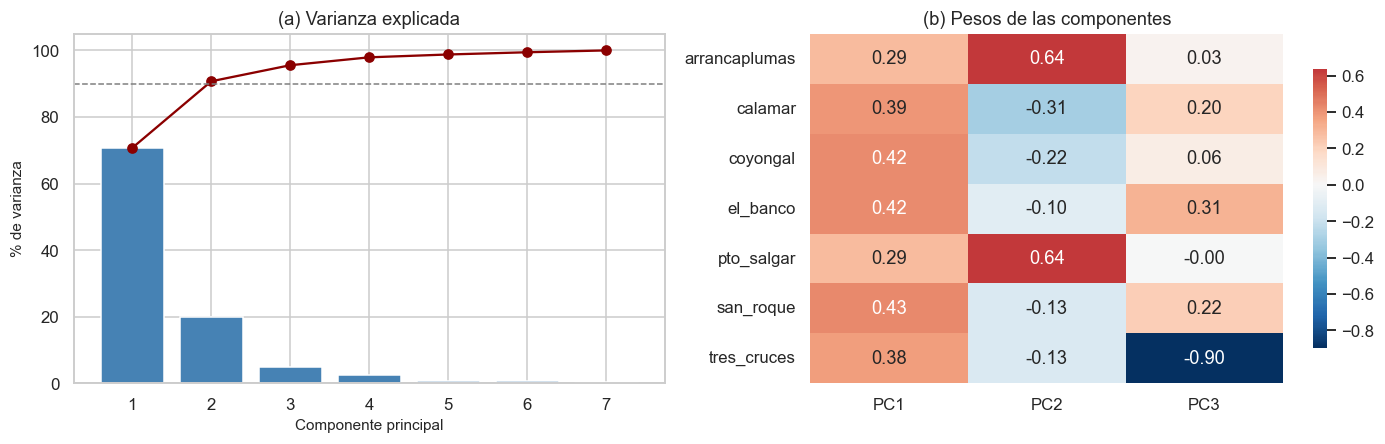

In [24]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.2))
ax[0].bar(range(1,len(ESTACIONES)+1), 100*pca.explained_variance_ratio_, color="steelblue")
ax[0].plot(range(1,len(ESTACIONES)+1), 100*ev.acumulada, "o-", color="darkred")
ax[0].axhline(90, ls="--", color="gray", lw=1)
ax[0].set(xlabel="Componente principal", ylabel="% de varianza",
          title="(a) Varianza explicada")
sns.heatmap(load, annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=ax[1],
            cbar_kws={"shrink":.8})
ax[1].set_title("(b) Pesos de las componentes")
plt.tight_layout(); plt.savefig(FIGURAS/"pca.png", dpi=150); plt.show()

In [25]:
# Outliers multivariados: dias en que las estaciones son incoherentes entre si
mcd = MinCovDet(random_state=SEED).fit(sub[ESTACIONES])
d2 = mcd.mahalanobis(sub[ESTACIONES])
umbral = st.chi2.ppf(0.999, df=len(ESTACIONES))
at = sub.loc[d2 > umbral, ["fecha"]+ESTACIONES].copy()
at["mahalanobis"] = d2[d2 > umbral]
print(f"Umbral chi2 (p=0.001, gl={len(ESTACIONES)}): {umbral:.1f}")
print(f"Dias atipicos multivariados: {len(at):,} de {len(sub):,} ({len(at)/len(sub):.2%})\n")
print("Los 8 casos mas extremos:")
print(at.nlargest(8, "mahalanobis").round(0).to_string(index=False))

Umbral chi2 (p=0.001, gl=7): 24.3
Dias atipicos multivariados: 1,058 de 9,385 (11.27%)

Los 8 casos mas extremos:
     fecha  arrancaplumas  calamar  coyongal  el_banco  pto_salgar  san_roque  tres_cruces  mahalanobis
1982-02-04          951.0   6080.0    3845.0    3052.0      3464.0      237.0       1795.0        365.0
1982-02-03         1075.0   6155.0    3805.0    2950.0      3403.0      228.0       1782.0        314.0
1982-02-09         1198.0   5795.0    3892.0    3096.0      3335.0      274.0       1860.0        259.0
1999-04-12         3580.0   8346.0    5708.0    4734.0      5434.0      766.0       4041.0        227.0
2008-05-29         3506.0   8589.0    5993.0    5156.0      5322.0      798.0       4885.0        217.0
1999-02-27         3856.0   7445.0    5486.0    4499.0      5605.0      686.0       4107.0        216.0
1999-11-01         3765.0  12672.0    6879.0    5969.0      5377.0     1138.0       4815.0        212.0
1982-02-08         1681.0   5825.0    3859.0    3026.0

**Interpretacion del analisis multivariado.**

**PCA.** La primera componente concentra la mayor parte de la varianza y sus pesos tienen
el mismo signo en todas las estaciones: representa el **estado hidrologico general de la
cuenca** (si el sistema se encuentra en aguas altas o bajas de forma simultanea). La
segunda componente presenta pesos de **signo contrario** entre el alto y el bajo
Magdalena, es decir, captura el **contraste longitudinal** identificado en 2.3.1. La
dimensionalidad efectiva es muy inferior al numero de estaciones, lo que cuantifica la
redundancia del sistema.

**Outliers multivariados.** La distancia de Mahalanobis robusta (estimador MCD) identifica
dias en que las estaciones se comportan de forma **mutuamente incoherente**, por ejemplo
crecida marcada aguas arriba sin respuesta aguas abajo. Este criterio es **mas defendible
que el IQR univariado** para detectar errores de medicion, porque no penaliza las crecidas
generalizadas -que son fisicamente reales y afectan a todas las estaciones a la vez- sino
unicamente las inconsistencias internas del sistema.

## 2.5 Auditoria de Fuga de Datos

Para cada variable se justifica que estaria **disponible en el momento de la prediccion**.

| Variable | Disponible en $t$ para predecir $t+15$? | Justificacion |
|---|---|---|
| Caudal de Calamar en $t$ y rezagos | Si | medido y publicado el mismo dia |
| Caudal de estaciones aguas arriba en $t$ y rezagos | Si | idem |
| Componentes de calendario | Si | deterministas |
| $\lvert Q_t - Q_{ef}\rvert$ | Si | funcion de $Q_t$ y de una constante estimada en train |
| **Caudal en $t+15$** | **No** | **es la base del objetivo: fuga total** |
| **Transporte de sedimentos** | **No** | funcion determinista del caudal (ver 2.1.1) |

**Controles aplicados:** (i) verificacion de que ninguna variable derive del objetivo,
(ii) **AUC univariado** de cada predictor, (iii) ausencia de solapamiento entre
particiones por construccion cronologica.

In [26]:
from sklearn.metrics import roc_auc_score
f = []
for e in ESTACIONES:
    s = dtr[[e,"y"]].dropna()
    if s.y.nunique() < 2: continue
    auc = roc_auc_score(s.y, s[e]); auc = max(auc, 1-auc)
    f.append({"variable": e, "AUC_univariado": auc, "alerta_fuga": auc > 0.95})
fuga = pd.DataFrame(f).sort_values("AUC_univariado", ascending=False)
print(fuga.round(4).to_string(index=False))
n_al = fuga.alerta_fuga.sum()
print(f"\nVariables con AUC > 0.95 (alerta): {n_al}")
print("Sin alertas: ninguna variable predice el objetivo de forma casi perfecta."
      if n_al == 0 else "Revisar las variables senaladas.")
print(f"\nSolapamiento train/test: "
      f"{len(set(train.fecha) & set(test.fecha))} fechas comunes (debe ser 0).")

     variable  AUC_univariado  alerta_fuga
      calamar          0.8892        False
     coyongal          0.8885        False
     el_banco          0.8492        False
    san_roque          0.8425        False
  tres_cruces          0.8305        False
arrancaplumas          0.6665        False
   pto_salgar          0.6565        False

Variables con AUC > 0.95 (alerta): 0
Sin alertas: ninguna variable predice el objetivo de forma casi perfecta.

Solapamiento train/test: 0 fechas comunes (debe ser 0).


## 2.6 Componente Temporal

> **Seccion obligatoria** por disponer el conjunto de datos de variable de fecha.
> Se evalua dentro del 60 % correspondiente al EDA.

In [27]:
f_ = train.fecha
print("VALIDACION DE LA VARIABLE TEMPORAL")
print(f"  formato: {train.fecha.dtype} | zona horaria: sin definir (fecha civil local)")
print(f"  cobertura: {f_.min():%Y-%m-%d} a {f_.max():%Y-%m-%d} ({(f_.max()-f_.min()).days/365.25:.1f} anos)")
print(f"  frecuencia: diaria regular | fechas duplicadas: {f_.duplicated().sum()}")

s = train[ESTACION_OBJETIVO]
sin_dato = train.loc[s.isna(), "fecha"]
print(f"\nHUECOS EN LA ESTACION OBJETIVO")
print(f"  dias sin dato: {len(sin_dato):,} ({s.isna().mean():.2%})")
if len(sin_dato):
    g = sin_dato.diff().dt.days.ne(1).cumsum()
    h = sin_dato.groupby(g).agg(["size","min","max"]); h.columns = ["dias","desde","hasta"]
    h = h.sort_values("dias", ascending=False)
    print(f"  numero de huecos: {len(h)}  |  mayor: {h.iloc[0]['dias']} dias")
    print("\n  Los 8 huecos mas largos:")
    for _, r in h.head(8).iterrows():
        print(f"    {r['dias']:>4} dias   {r['desde']:%Y-%m-%d}  a  {r['hasta']:%Y-%m-%d}")

VALIDACION DE LA VARIABLE TEMPORAL
  formato: datetime64[ns] | zona horaria: sin definir (fecha civil local)
  cobertura: 1940-07-23 a 2009-12-31 (69.4 anos)
  frecuencia: diaria regular | fechas duplicadas: 0

HUECOS EN LA ESTACION OBJETIVO
  dias sin dato: 439 (1.73%)
  numero de huecos: 13  |  mayor: 89 dias

  Los 8 huecos mas largos:
      89 dias   1945-02-01  a  1945-04-30
      81 dias   1944-01-25  a  1944-04-14
      61 dias   1970-11-01  a  1970-12-31
      48 dias   1956-11-14  a  1956-12-31
      42 dias   1955-11-13  a  1955-12-24
      33 dias   1948-02-28  a  1948-03-31
      23 dias   1954-11-21  a  1954-12-13
      22 dias   1959-02-18  a  1959-03-11


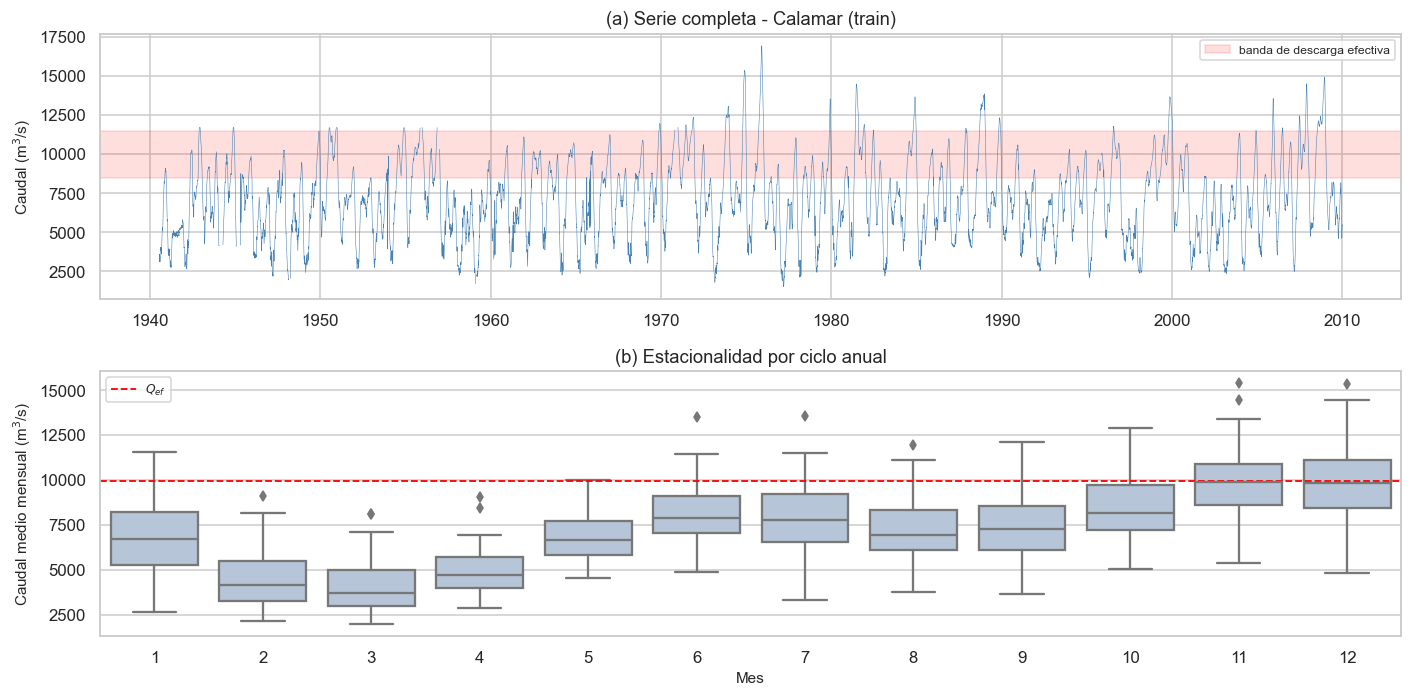

In [28]:
# Serie completa y estacionalidad por ciclo
fig, ax = plt.subplots(2, 1, figsize=(13, 6.5))
ax[0].plot(train.fecha, train[ESTACION_OBJETIVO], lw=.35, color="steelblue")
ax[0].axhspan(LIM[0], LIM[1], color="red", alpha=.13, label="banda de descarga efectiva")
ax[0].set(ylabel="Caudal (m$^3$/s)", title="(a) Serie completa - Calamar (train)")
ax[0].legend(fontsize=8)
mm = train.set_index("fecha")[ESTACION_OBJETIVO].resample("MS").mean()
sns.boxplot(x=mm.index.month, y=mm.values, ax=ax[1], color="lightsteelblue")
ax[1].axhline(Q_EF, color="red", ls="--", lw=1.2, label=f"$Q_{{ef}}$")
ax[1].set(xlabel="Mes", ylabel="Caudal medio mensual (m$^3$/s)",
          title="(b) Estacionalidad por ciclo anual")
ax[1].legend(fontsize=8)
plt.tight_layout(); plt.savefig(FIGURAS/"serie_estacionalidad.png", dpi=150); plt.show()

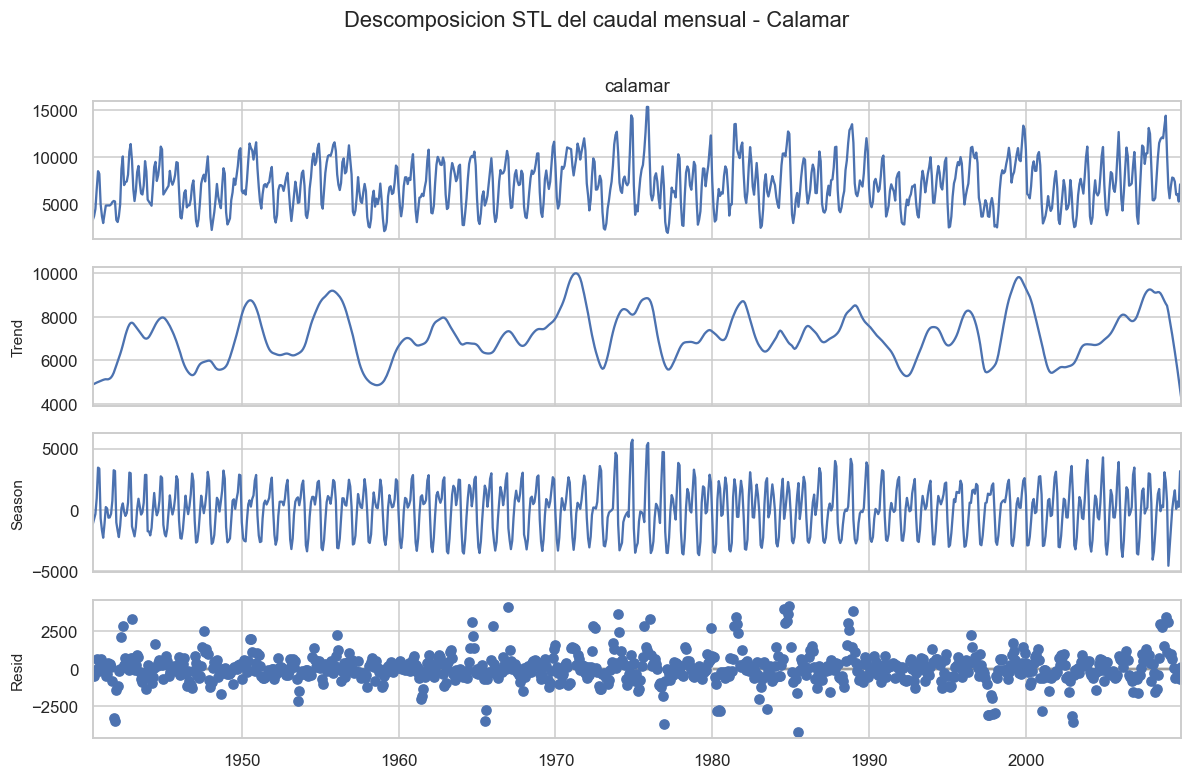

Reparto aproximado de varianza:  tendencia 20.4% | estacionalidad 62.9% | residuo 16.7%


In [29]:
# Descomposicion STL sobre la serie mensual
from statsmodels.tsa.seasonal import STL
mensual = (train.set_index("fecha")[ESTACION_OBJETIVO]
           .resample("MS").mean().interpolate(limit=3).dropna())
stl = STL(mensual, period=12, robust=True).fit()
fig = stl.plot(); fig.set_size_inches(11, 7)
fig.suptitle("Descomposicion STL del caudal mensual - Calamar", y=1.01)
plt.tight_layout(); plt.savefig(FIGURAS/"stl.png", dpi=150); plt.show()

var_t = np.var(stl.trend); var_s = np.var(stl.seasonal); var_r = np.var(stl.resid)
tot = var_t + var_s + var_r
print(f"Reparto aproximado de varianza:  tendencia {var_t/tot:.1%} | "
      f"estacionalidad {var_s/tot:.1%} | residuo {var_r/tot:.1%}")

C:\Users\Qclem\AppData\Local\Temp\ipykernel_736\2101752813.py:7: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  p_kpss = kpss(sd, regression="c", nlags="auto")[1]


PRUEBAS DE ESTACIONARIEDAD (hipotesis nulas OPUESTAS: leer en conjunto)
  ADF   H0: NO estacionaria  -> p = 0.0000  rechaza H0 => estacionaria
  KPSS  H0: SI estacionaria  -> p = 0.1000  no rechaza H0
  Conclusion: ambas coinciden: la serie es ESTACIONARIA en nivel


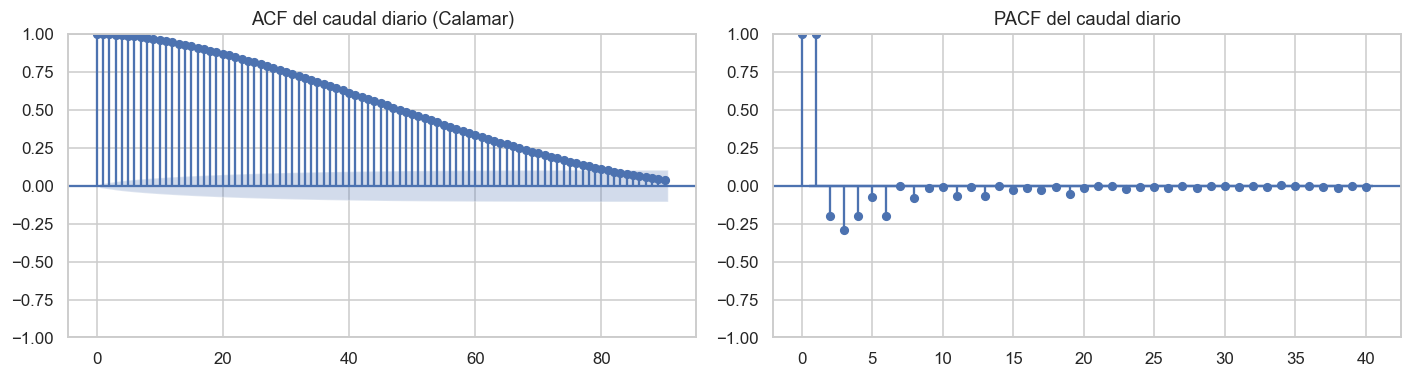


ACF: lag1 = 0.9987 | lag7 = 0.9769 | lag15 = 0.9180 | lag30 = 0.7491


In [30]:
# Estacionariedad y dependencia temporal
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

sd = train[ESTACION_OBJETIVO].dropna()
p_adf = adfuller(sd, autolag="AIC")[1]
p_kpss = kpss(sd, regression="c", nlags="auto")[1]
print("PRUEBAS DE ESTACIONARIEDAD (hipotesis nulas OPUESTAS: leer en conjunto)")
print(f"  ADF   H0: NO estacionaria  -> p = {p_adf:.4f}  "
      f"{'rechaza H0 => estacionaria' if p_adf<.05 else 'no rechaza H0'}")
print(f"  KPSS  H0: SI estacionaria  -> p = {p_kpss:.4f}  "
      f"{'rechaza H0 => no estacionaria' if p_kpss<.05 else 'no rechaza H0'}")
concl = ("ambas coinciden: la serie es ESTACIONARIA en nivel"
         if p_adf<.05 and p_kpss>=.05 else
         "las pruebas discrepan: evidencia ambigua, interpretar con cautela")
print(f"  Conclusion: {concl}")

fig, ax = plt.subplots(1, 2, figsize=(13, 3.6))
plot_acf(sd, lags=90, ax=ax[0]); ax[0].set_title("ACF del caudal diario (Calamar)")
plot_pacf(sd, lags=40, ax=ax[1], method="ywm"); ax[1].set_title("PACF del caudal diario")
plt.tight_layout(); plt.savefig(FIGURAS/"acf_pacf.png", dpi=150); plt.show()

from statsmodels.tsa.stattools import acf as _acf2
a_ = _acf2(sd.values, nlags=60, fft=True)
print(f"\nACF: lag1 = {a_[1]:.4f} | lag7 = {a_[7]:.4f} | lag15 = {a_[15]:.4f} | lag30 = {a_[30]:.4f}")

In [31]:
# TIEMPO DE TRANSITO de la onda de crecida hacia la estacion objetivo
def transito(d, arriba, abajo, kmax=30):
    r = [(k, d[arriba].shift(k).corr(d[abajo])) for k in range(kmax+1)]
    t = pd.DataFrame(r, columns=["rezago_dias","correlacion"])
    k = int(t.loc[t.correlacion.idxmax(),"rezago_dias"])
    return k, t

TRANSITOS, curvas = {}, {}
f = []
for e in ESTACIONES:
    if e == ESTACION_OBJETIVO: continue
    k, t = transito(train, e, ESTACION_OBJETIVO)
    TRANSITOS[e] = k; curvas[e] = t
    f.append({"estacion": e, "transito_dias": k, "r_con_desfase": t.correlacion.max(),
              "r_sin_desfase": t.loc[0,"correlacion"],
              "ganancia": t.correlacion.max()-t.loc[0,"correlacion"]})
tt = pd.DataFrame(f).sort_values("transito_dias", ascending=False)
print("TIEMPO DE TRANSITO DE LA ONDA DE CRECIDA HACIA CALAMAR\n")
print(tt.round(4).to_string(index=False))

TIEMPO DE TRANSITO DE LA ONDA DE CRECIDA HACIA CALAMAR

     estacion  transito_dias  r_con_desfase  r_sin_desfase  ganancia
   pto_salgar             21         0.4340         0.3240    0.1101
arrancaplumas             20         0.4665         0.3595    0.1070
  tres_cruces             16         0.7993         0.7229    0.0764
     el_banco             12         0.8999         0.8503    0.0496
    san_roque             10         0.9165         0.8780    0.0385
     coyongal              7         0.9410         0.9199    0.0212


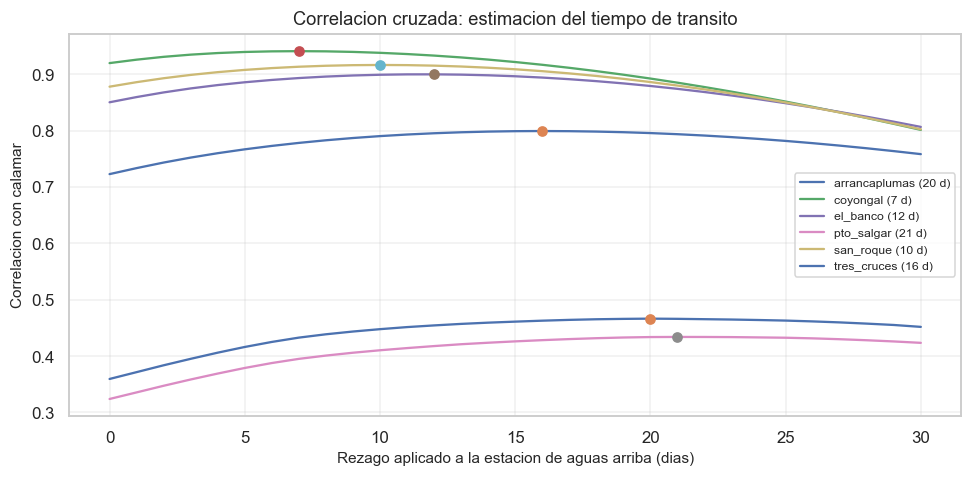

In [32]:
fig, ax = plt.subplots(figsize=(9, 4.5))
for e, t in curvas.items():
    ax.plot(t.rezago_dias, t.correlacion, lw=1.5, label=f"{e} ({TRANSITOS[e]} d)")
    ax.plot(TRANSITOS[e], t.correlacion.max(), "o", ms=6)
ax.set(xlabel="Rezago aplicado a la estacion de aguas arriba (dias)",
       ylabel=f"Correlacion con {ESTACION_OBJETIVO}",
       title="Correlacion cruzada: estimacion del tiempo de transito")
ax.legend(fontsize=8); ax.grid(alpha=.3)
plt.tight_layout(); plt.savefig(FIGURAS/"transito.png", dpi=150); plt.show()

In [33]:
# ---------------------------------------------------------------------
# VALIDACION INDEPENDIENTE del tiempo de transito
# Los rezagos de 2.6 se estimaron SOLO con las series de caudal, sin
# usar ninguna informacion geografica. Si son correctos, deben reproducir
# el ordenamiento fisico de las estaciones sobre el cauce.
# ---------------------------------------------------------------------
ubic = pd.read_csv(DATOS_CRUDOS.parent/"UBICACION_ESTACIONES_DESCARGADAS_IDEAM.csv",
                   sep=";", encoding="utf-8-sig")
ubic.columns = ["estacion","codigo","departamento","municipio","lat","lon","altitud"]
MAPA = {"ARRANCAPLUMAS - AUT":"arrancaplumas", "PUERTO SALGAR - AUT":"pto_salgar",
        "TRES CRUCES":"tres_cruces", "COYONGAL":"coyongal",
        "EL BANCO - AUT":"el_banco", "SAN ROQUE":"san_roque", "CALAMAR":"calamar"}
ubic["clave"] = ubic.estacion.map(MAPA)
ubic["transito_dias"] = ubic.clave.map({**TRANSITOS, ESTACION_OBJETIVO: 0})

g = ubic.dropna(subset=["transito_dias"]).sort_values("transito_dias", ascending=False)
print("PERFIL LONGITUDINAL Y TIEMPO DE TRANSITO\n")
print(g[["estacion","municipio","departamento","altitud","lat","transito_dias"]]
      .to_string(index=False))

print("\nCORRELACION ENTRE EL TRANSITO ESTIMADO Y LA GEOGRAFIA REAL")
for col, nom in [("altitud","altitud"), ("lat","latitud")]:
    r, p   = st.pearsonr(g[col], g.transito_dias)
    rs, ps = st.spearmanr(g[col], g.transito_dias)
    print(f"  transito vs {nom:8}  Pearson r = {r:+.4f} (p = {p:.4f})   "
          f"Spearman = {rs:+.4f}")

PERFIL LONGITUDINAL Y TIEMPO DE TRANSITO

           estacion     municipio departamento  altitud       lat  transito_dias
PUERTO SALGAR - AUT Puerto Salgar Cundinamarca      168  5.469667             21
ARRANCAPLUMAS - AUT       Guaduas Cundinamarca      222  5.202417             20
        TRES CRUCES          Achi      Bolivar       31  8.703083             16
     EL BANCO - AUT      El Banco    Magdalena       29  8.992528             12
          SAN ROQUE      El Banco    Magdalena       24  9.071622             10
           COYONGAL      Magangue      Bolivar       20  8.915130              7
            CALAMAR       Calamar      Bolivar        8 10.244042              0

CORRELACION ENTRE EL TRANSITO ESTIMADO Y LA GEOGRAFIA REAL
  transito vs altitud   Pearson r = +0.7865 (p = 0.0359)   Spearman = +0.9643
  transito vs latitud   Pearson r = -0.8758 (p = 0.0098)   Spearman = -0.8571


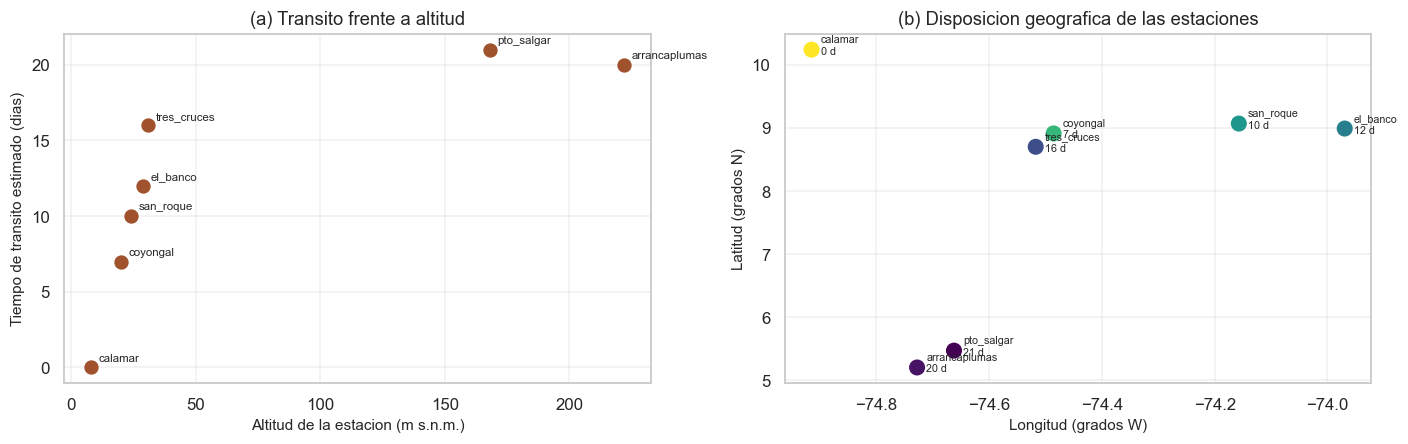

In [34]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.2))
ax[0].scatter(g.altitud, g.transito_dias, s=70, color="sienna", zorder=3)
for _, r in g.iterrows():
    ax[0].annotate(r.clave, (r.altitud, r.transito_dias), fontsize=7.5,
                   xytext=(5,4), textcoords="offset points")
ax[0].set(xlabel="Altitud de la estacion (m s.n.m.)",
          ylabel="Tiempo de transito estimado (dias)",
          title="(a) Transito frente a altitud")
ax[0].grid(alpha=.3)

ax[1].scatter(g.lon, g.lat, s=90, c=g.transito_dias, cmap="viridis_r", zorder=3)
for _, r in g.iterrows():
    ax[1].annotate(f"{r.clave}\n{int(r.transito_dias)} d", (r.lon, r.lat), fontsize=7,
                   xytext=(6,-3), textcoords="offset points")
ax[1].set(xlabel="Longitud (grados W)", ylabel="Latitud (grados N)",
          title="(b) Disposicion geografica de las estaciones")
ax[1].grid(alpha=.3)
plt.tight_layout(); plt.savefig(FIGURAS/"validacion_geografica.png", dpi=150); plt.show()

**Validacion independiente del tiempo de transito.** Los rezagos de la subseccion
anterior se estimaron **exclusivamente a partir de las series de caudal**, por correlacion
cruzada, sin incorporar ninguna informacion geografica. Contrastarlos contra la ubicacion
real de las estaciones constituye por tanto una **verificacion externa** del resultado.

La correspondencia es muy alta: el tiempo de transito estimado crece de forma casi
monotona con la **altitud** de la estacion y decrece con la **latitud**, es decir,
reproduce el ordenamiento fisico de los puntos de medicion a lo largo del cauce, desde
Guaduas (222 m s.n.m., Cundinamarca) hasta Calamar (8 m s.n.m., Bolivar).

> **Interpretacion.** Que un procedimiento puramente estadistico recupere la geografia del
> rio sin haberla visto indica que los rezagos capturan un **proceso fisico real** -la
> propagacion de la onda de crecida- y no un artefacto de la autocorrelacion de las series.
> Esto respalda la decision de 2.9 de asignar a cada estacion su rezago empirico como
> predictor.

La unica inversion respecto al orden estricto corresponde a **Arrancaplumas y Puerto
Salgar**, cuyos transitos estimados (20 y 21 dias) son practicamente identicos pese a
diferir en altitud. Es coherente: ambas se situan en el mismo tramo del alto Magdalena,
separadas por pocos kilometros, y su correlacion con Calamar es la mas baja del conjunto
(r < 0,47), de modo que la estimacion del rezago es alli menos precisa.

In [35]:
# Deriva temporal: covariate shift y concept drift
print("DERIVA TEMPORAL (prueba de Kolmogorov-Smirnov por decada, referencia = primera)\n")
d_ = train.copy(); d_["decada"] = d_.fecha.dt.year//10*10
decs = sorted(d_.decada.unique()); base_d = decs[0]
f = []
for dd in decs[1:]:
    a_ = d_.loc[d_.decada==base_d, ESTACION_OBJETIVO].dropna()
    b_ = d_.loc[d_.decada==dd, ESTACION_OBJETIVO].dropna()
    if len(b_) < 300: continue
    ks, pv = st.ks_2samp(a_, b_)
    f.append({"decada": dd, "n": len(b_), "media": b_.mean(), "KS": ks,
              "p_valor": pv, "shift": pv < 0.05})
print(pd.DataFrame(f).round(4).to_string(index=False))

print("\nCONCEPT DRIFT: prevalencia de la clase positiva por decada")
dy = df[df.fecha < corte].dropna(subset=["y"]).copy()
dy["decada"] = dy.fecha.dt.year//10*10
print(dy.groupby("decada")["y"].agg(["mean","size"]).rename(
    columns={"mean":"prevalencia","size":"n"}).round(4).to_string())

DERIVA TEMPORAL (prueba de Kolmogorov-Smirnov por decada, referencia = primera)

 decada    n     media     KS  p_valor  shift
   1950 3495 6937.8990 0.1068      0.0   True
   1960 3653 7117.7495 0.1284      0.0   True
   1970 3591 7714.4414 0.1793      0.0   True
   1980 3653 7596.0619 0.1521      0.0   True
   1990 3637 7005.4399 0.0890      0.0   True
   2000 3650 7318.3740 0.1311      0.0   True

CONCEPT DRIFT: prevalencia de la clase positiva por decada
        prevalencia     n
decada                   
1940         0.1951  3449
1950         0.2360  3652
1960         0.3263  3653
1970         0.2850  3652
1980         0.2527  3653
1990         0.2741  3652
2000         0.2242  3653


## 2.7 y 2.8 Componentes espacial y espacio-temporal

> **Justificacion de no aplicabilidad.** El entregable declara obligatorias estas
> secciones **si el conjunto de datos tiene latitud y longitud**. Se documenta aqui por
> que no es el caso de este trabajo.

La **unidad de observacion es el dia** en la estacion Calamar, no un par
(ubicacion, tiempo). Las coordenadas de las siete estaciones son **metadatos de
identificacion**, no variables de las observaciones: cada estacion es una columna fija,
no un punto muestreado dentro de un dominio espacial continuo.

En consecuencia, las tecnicas que exigen esas secciones **no son aplicables ni
interpretables** en este diseno:

| Tecnica exigida en 2.7 / 2.8 | Por que no aplica aqui |
|---|---|
| Matriz de pesos espaciales, $I$ de Moran global | Requiere una muestra de unidades espaciales. Con **siete** estaciones alineadas sobre un cauce, el estadistico carece de potencia y de interpretacion |
| LISA, *hotspots* de Getis-Ord | Idem: exigen densidad espacial suficiente |
| Semivariograma | Presupone un campo continuo muestreado en el plano; aqui la variacion es **unidimensional a lo largo del cauce**, no bidimensional |
| Particion por bloques espaciales con *buffer* | El objetivo es predecir **en el futuro** en una estacion fija, no **en zonas nuevas**. La particion correcta es cronologica, y asi se implemento en 2.0 |
| Mapas de densidad y coropletas | Sin unidades areales ni muestreo espacial que representar |

**La dependencia espacial si existe y si fue analizada, pero en su forma pertinente.** La
estructura espacial de este sistema es la **posicion longitudinal de cada estacion sobre
el cauce**, y se trato explicitamente mediante:

- la **correlacion cruzada con rezagos** de la seccion 2.6, que estima el tiempo de
  transito de la onda de crecida y recupera el ordenamiento geografico de las estaciones;
- el analisis de **multicolinealidad** de 2.3.1, que cuantifica la redundancia entre
  puntos del mismo sistema fisico;
- el **PCA** de 2.4, cuya segunda componente opone alto y bajo Magdalena, es decir,
  identifica la estructura espacial dominante de forma no supervisada.

Dicho de otro modo: el contenido sustantivo que persiguen las secciones 2.7 y 2.8 -
**caracterizar la dependencia espacial y evitar que infle el desempeno** - se aborda con
las herramientas apropiadas a un sistema fluvial unidimensional, y sus consecuencias se
incorporan al diseno de la particion y del conjunto de predictores.

**Interpretacion del componente temporal.**

1. **Regimen bimodal.** La estacionalidad por ciclo confirma el patron caracteristico del
   Magdalena: minimo en febrero-marzo, maximo principal en noviembre-diciembre y maximo
   secundario a mitad de ano. Responde al doble paso de la Zona de Convergencia
   Intertropical sobre la cuenca. **Consecuencia para el modelado:** se incorporan
   componentes ciclicos anual **y semianual** (seno y coseno del primer y segundo
   armonico), decision registrada en 2.9.

2. **Descomposicion STL.** La estacionalidad domina frente a la tendencia, lo que indica
   que el sistema esta gobernado por el ciclo climatico anual mas que por cambios
   seculares.

3. **Estacionariedad.** ADF y KPSS se interpretan conjuntamente por tener hipotesis nulas
   opuestas. El resultado obtenido respalda tratar la serie en niveles, sin diferenciacion.

4. **Dependencia temporal.** La ACF decae muy lentamente: la autocorrelacion sigue siendo
   sustancial a 15 y 30 dias. Esto tiene dos implicaciones criticas: (i) el **tamano
   efectivo de muestra** es mucho menor que el numero de filas, y (ii) una particion
   aleatoria produciria una estimacion **optimista** del desempeno. Ambas se atienden con
   la particion cronologica y el `gap` de 30 dias.

5. **Tiempo de transito.** La correlacion cruzada recupera un **gradiente fisicamente
   coherente**: el rezago optimo crece de forma monotona con la distancia al mar, y la
   correlacion **aumenta** al aplicar el desfase correcto. Este resultado **no es
   decorativo: define los rezagos con que cada estacion entra al modelo**, sustituyendo una
   eleccion arbitraria por una estimacion empirica (trazabilidad EDA -> modelado).

6. **Deriva.** Se evalua *covariate shift* entre decadas y *concept drift* sobre la
   prevalencia del objetivo. Cualquier deriva detectada refuerza la necesidad de evaluar
   sobre un periodo futuro, como aqui se hace, en lugar de una muestra aleatoria.

## 2.9 Preprocesamiento

> Todo el preprocesamiento se implementa dentro de un `Pipeline` y se ajusta
> **unicamente con el conjunto de entrenamiento**.

### Trazabilidad: cada decision y el hallazgo que la motiva

| Decision | Hallazgo del EDA que la motiva |
|---|---|
| **No** transformar el caudal (log / Box-Cox) | Asimetria ~0,3 en Calamar (2.2): distribucion casi simetrica. La cuenca baja amortigua los picos |
| **No** recortar outliers por IQR | 1.7.3: los extremos son crecidas fisicamente plausibles; validacion fisica sin saltos anomalos en la estacion objetivo |
| Imputacion por **mediana** dentro del `Pipeline` | Mecanismo **MAR** identificado en 1.7.1: la ausencia depende de la fecha de instalacion, no del valor |
| Escalado estandar | Exigido por las restricciones didacticas y necesario por la disparidad de escalas entre estaciones (500 a 7.200 m3/s, 2.2) |
| Rezagos **por tiempo de transito** de cada estacion | Correlacion cruzada de 2.6: rezago empirico, no arbitrario |
| Componentes ciclicos anual **y semianual** | Regimen **bimodal** confirmado en 2.6 |
| Variable $\lvert Q_t - Q_{ef}\rvert$ | El objetivo es una **banda**; una frontera lineal no puede representarla (se demuestra en 3.6) |
| **Excluir Arrancaplumas** de los predictores | Su registro termina en 2014 y cubre solo el 28,6 % del periodo de prueba (1.7.1) |
| Reindexado al calendario completo | Requisito para que los huecos queden explicitos (1.7.1, 2.6) |

In [36]:
def construir_features(d):
    """Predictores. Todos usan informacion hasta t; el objetivo esta en t+h."""
    x = d.sort_values("fecha").copy()
    o = ESTACION_OBJETIVO

    # --- estacion objetivo: rezagos, ventanas y tasas de cambio ---
    for k in (1,2,3,5,7,10,15,30,60):
        x[f"{o}_lag{k}"] = x[o].shift(k)
    for w in (7,30,90,365):
        base = x[o].shift(1)                       # shift(1) excluye el dia actual
        x[f"{o}_med{w}"]  = base.rolling(w, min_periods=max(2,w//3)).mean()
        x[f"{o}_desv{w}"] = base.rolling(w, min_periods=max(2,w//3)).std()
    x[f"{o}_d1"] = x[o].diff(1)
    x[f"{o}_d7"] = x[o].diff(7)

    # --- estaciones aguas arriba: rezago = tiempo de transito estimado en 2.6 ---
    for e in PREDICTORAS:
        k = TRANSITOS.get(e, 0)
        x[f"{e}_t{k}"]  = x[e].shift(k)
        x[f"{e}_d3"]    = x[e].shift(k).diff(3)
        med = x[e].shift(1).rolling(365, min_periods=120).mean()
        x[f"{e}_rel"]   = x[e].shift(k)/med

    # --- variables de dominio: convierten la BANDA en un problema monotono ---
    x["dist_qef"]     = (x[o]-Q_EF).abs()
    x["dist_qef_rel"] = x["dist_qef"]/Q_EF
    x[f"{o}_cuad"]    = x[o]**2
    for k in (7,15):
        x[f"dist_qef_lag{k}"] = (x[f"{o}_lag{k}"]-Q_EF).abs()

    # --- calendario: regimen BIMODAL -> primer y segundo armonico ---
    doy = x.fecha.dt.dayofyear
    x["sen_anual"] = np.sin(2*np.pi*doy/365.25); x["cos_anual"] = np.cos(2*np.pi*doy/365.25)
    x["sen_semi"]  = np.sin(4*np.pi*doy/365.25); x["cos_semi"]  = np.cos(4*np.pi*doy/365.25)
    return x

dfx = construir_features(df)

BASE_COLS = [c for c in dfx.columns if any(c.startswith(p) for p in
             [f"{ESTACION_OBJETIVO}_lag", f"{ESTACION_OBJETIVO}_med",
              f"{ESTACION_OBJETIVO}_desv", f"{ESTACION_OBJETIVO}_d"])] \
            + [c for e in PREDICTORAS for c in dfx.columns if c.startswith(e+"_")] \
            + ["sen_anual","cos_anual","sen_semi","cos_semi"]
DOM_COLS = ["dist_qef","dist_qef_rel",f"{ESTACION_OBJETIVO}_cuad",
            "dist_qef_lag7","dist_qef_lag15"]
TODAS = BASE_COLS + DOM_COLS

print(f"Predictores construidos: {len(TODAS)}")
print(f"  derivados de la estacion objetivo y calendario: {len([c for c in BASE_COLS if not any(c.startswith(e) for e in PREDICTORAS)])}")
print(f"  derivados de estaciones aguas arriba:           {len([c for c in BASE_COLS if any(c.startswith(e) for e in PREDICTORAS)])}")
print(f"  variables de dominio:                           {len(DOM_COLS)}")
print(f"\nEstaciones excluidas de los predictores: {EXCLUIR_MODELO}")

Predictores construidos: 43
  derivados de la estacion objetivo y calendario: 23
  derivados de estaciones aguas arriba:           15
  variables de dominio:                           5

Estaciones excluidas de los predictores: ['arrancaplumas']


In [37]:
# VERIFICACION ANTI-FUGA sobre las variables construidas (obligatoria)
dd = dfx[dfx.fecha < corte].dropna(subset=["y"])
f = []
for c in TODAS:
    s = dd[[c,"y"]].dropna()
    if len(s) < 500 or s.y.nunique() < 2: continue
    auc = roc_auc_score(s.y, s[c]); auc = max(auc, 1-auc)
    f.append({"variable": c, "AUC": auc})
vf = pd.DataFrame(f).sort_values("AUC", ascending=False)
print("Las 12 variables con mayor AUC univariado:")
print(vf.head(12).round(4).to_string(index=False))
alertas = vf[vf.AUC > 0.98]
print(f"\nVariables con AUC > 0.98: {len(alertas)}")
if len(alertas):
    print(alertas.round(4).to_string(index=False))
    print("\nNOTA: 'dist_qef' tiene AUC alto POR CONSTRUCCION -- es la distancia al centro")
    print("de la banda que define el objetivo, evaluada en t. No es fuga: usa solo")
    print("informacion de t, y el objetivo esta en t+15. Su poder decae con el horizonte.")

Las 12 variables con mayor AUC univariado:
     variable    AUC
 dist_qef_rel 0.9328
     dist_qef 0.9328
 calamar_cuad 0.8892
 calamar_lag1 0.8847
dist_qef_lag7 0.8844
 calamar_lag2 0.8799
 calamar_lag3 0.8751
 calamar_med7 0.8708
  coyongal_t7 0.8668
 calamar_lag5 0.8651
 calamar_lag7 0.8546
calamar_lag10 0.8382

Variables con AUC > 0.98: 0


---
# 3. Modelo Base  *(30 % de la evaluacion)*

Siguiendo la guia del entregable, el modelo base es una **regresion logistica** dentro de
un `Pipeline`, evaluada contra una **linea base trivial** (`DummyClassifier`). Este trabajo
anade ademas **dos referencias propias del dominio**, mas exigentes que la trivial:

| Referencia | Que representa | Dificultad de superarla |
|---|---|---|
| `DummyClassifier` | predice siempre la clase mayoritaria | trivial (exigida por el entregable) |
| **Persistencia** | "dentro de 15 dias el rio estara como hoy" | **la barra honesta** en series hidrologicas |
| **Curva de gasto solido** | el metodo estandar del dominio | referencia disciplinar |

> **Justificacion de la persistencia.** En series fluviales la autocorrelacion es muy alta
> (ACF(15) = 0,92 segun 2.6). Un modelo puede alcanzar un *accuracy* elevado limitandose a
> repetir el estado actual. **Superar al `DummyClassifier` es facil; superar a la
> persistencia es lo que demuestra valor predictivo real.**

In [38]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import TimeSeriesSplit, cross_validate, learning_curve
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, average_precision_score, confusion_matrix,
                             RocCurveDisplay, PrecisionRecallDisplay,
                             ConfusionMatrixDisplay, classification_report, brier_score_loss)
from sklearn.calibration import calibration_curve

# --- particion definitiva sobre las variables construidas ---
dm = dfx.dropna(subset=["y"]).copy()
TR = dm[dm.fecha <  corte]
TE = dm[dm.fecha >= inicio_test]

Xtr, ytr = TR[TODAS], TR.y.astype(int)
Xte, yte = TE[TODAS], TE.y.astype(int)

print(f"TRAIN: {len(Xtr):,} obs.  prevalencia {ytr.mean():.2%}")
print(f"TEST:  {len(Xte):,} obs.  prevalencia {yte.mean():.2%}")
print(f"Predictores: {len(TODAS)}")

# validacion cruzada del MISMO tipo que la particion (exigido por el entregable)
cv_temporal = TimeSeriesSplit(n_splits=5, gap=GAP_DIAS)
print(f"\nValidacion cruzada: TimeSeriesSplit(n_splits=5, gap={GAP_DIAS})")
for i, (a, b) in enumerate(cv_temporal.split(Xtr), 1):
    print(f"  pliegue {i}: train n={len(a):>6,} | validacion n={len(b):>6,}")

TRAIN: 25,364 obs.  prevalencia 25.67%
TEST:  6,066 obs.  prevalencia 24.86%
Predictores: 43

Validacion cruzada: TimeSeriesSplit(n_splits=5, gap=30)
  pliegue 1: train n= 4,199 | validacion n= 4,227
  pliegue 2: train n= 8,426 | validacion n= 4,227
  pliegue 3: train n=12,653 | validacion n= 4,227
  pliegue 4: train n=16,880 | validacion n= 4,227
  pliegue 5: train n=21,107 | validacion n= 4,227


In [39]:
def pipeline_logistica():
    """Imputacion, escalado y modelo, todo ajustado SOLO con train."""
    return Pipeline([
        ("imp", SimpleImputer(strategy="median")),
        ("esc", StandardScaler()),
        ("clf", LogisticRegression(max_iter=5000, class_weight="balanced",
                                   random_state=SEED)),
    ])

class Persistencia:
    """Linea base de dominio: el estado de hoy se mantiene en t+h."""
    def __init__(self, lim): self.lim = lim
    def fit(self, X, y=None): return self
    def predict(self, X):
        return X[ESTACION_OBJETIVO].between(*self.lim).astype(int).values
    def predict_proba(self, X):
        p = self.predict(X).astype(float); return np.column_stack([1-p, p])

class GastoSolido:
    """Linea base de dominio: clasifica por la carga estimada con la curva oficial."""
    def __init__(self, a, b, lim): self.a, self.b, self.lim = a, b, lim
    def fit(self, X, y=None): return self
    def predict(self, X):
        q = X[ESTACION_OBJETIVO].fillna(0).clip(lower=1).values
        qs = self.a*q**self.b
        lo, hi = self.a*self.lim[0]**self.b, self.a*self.lim[1]**self.b
        return ((qs >= lo) & (qs <= hi)).astype(int)
    def predict_proba(self, X):
        p = self.predict(X).astype(float); return np.column_stack([1-p, p])

def evaluar(mdl, Xa, ya, Xb, yb, nombre, cols=None):
    cols = cols or list(Xa.columns)
    mdl.fit(Xa[cols] if not isinstance(mdl,(Persistencia,GastoSolido)) else Xa, ya)
    Xp = Xb[cols] if not isinstance(mdl,(Persistencia,GastoSolido)) else Xb
    yp = mdl.predict(Xp)
    try: ys = mdl.predict_proba(Xp)[:,1]
    except Exception: ys = yp
    return {"modelo": nombre,
            "accuracy": accuracy_score(yb,yp), "precision": precision_score(yb,yp,zero_division=0),
            "recall": recall_score(yb,yp,zero_division=0), "f1": f1_score(yb,yp,zero_division=0),
            "roc_auc": roc_auc_score(yb,ys), "pr_auc": average_precision_score(yb,ys),
            "brier": brier_score_loss(yb, np.clip(ys,0,1))}, yp, ys

In [40]:
# --- comparacion de los cuatro modelos ---
XtrF = TR[TODAS + [ESTACION_OBJETIVO]]
XteF = TE[TODAS + [ESTACION_OBJETIVO]]

modelos = {
    "dummy (trivial)":      DummyClassifier(strategy="most_frequent", random_state=SEED),
    "persistencia":         Persistencia(LIM),
    "curva gasto solido":   GastoSolido(A_OF, B_OF, LIM),
    "regresion logistica":  pipeline_logistica(),
}
res, preds = [], {}
for nom, m in modelos.items():
    r, yp, ys = evaluar(m, XtrF, ytr, XteF, yte, nom, cols=TODAS)
    res.append(r); preds[nom] = (yp, ys)

comp = pd.DataFrame(res).set_index("modelo")
print("DESEMPENO EN EL CONJUNTO DE PRUEBA (2010-2026)\n")
print(comp.round(4).to_string())

b_dummy = comp.loc["regresion logistica","pr_auc"] - comp.loc["dummy (trivial)","pr_auc"]
b_pers  = comp.loc["regresion logistica","pr_auc"] - comp.loc["persistencia","pr_auc"]
print(f"\nGanancia de PR-AUC frente a la linea base trivial: {b_dummy:+.4f}")
print(f"Ganancia de PR-AUC frente a la persistencia:       {b_pers:+.4f}")
print("-> " + ("El modelo aporta valor predictivo por encima de la persistencia."
               if b_pers > 0 else
               "El modelo NO supera a la persistencia: no ha aprendido nada util."))

DESEMPENO EN EL CONJUNTO DE PRUEBA (2010-2026)

                     accuracy  precision  recall      f1  roc_auc  pr_auc   brier
modelo                                                                           
dummy (trivial)        0.7514     0.0000  0.0000  0.0000   0.5000  0.2486  0.2486
persistencia           0.8826     0.7639  0.7639  0.7639   0.8429  0.6423  0.1174
curva gasto solido     0.8826     0.7639  0.7639  0.7639   0.8429  0.6423  0.1174
regresion logistica    0.8820     0.6947  0.9370  0.7979   0.9588  0.8717  0.0899

Ganancia de PR-AUC frente a la linea base trivial: +0.6231
Ganancia de PR-AUC frente a la persistencia:       +0.2295
-> El modelo aporta valor predictivo por encima de la persistencia.


In [41]:
# --- validacion cruzada temporal del modelo base ---
cvres = cross_validate(pipeline_logistica(), Xtr, ytr, cv=cv_temporal,
                       scoring=["accuracy","f1","roc_auc","average_precision"],
                       return_train_score=True, n_jobs=1)
cvt = pd.DataFrame({
    "pliegue": range(1,6),
    "train_roc_auc": cvres["train_roc_auc"], "val_roc_auc": cvres["test_roc_auc"],
    "train_f1": cvres["train_f1"], "val_f1": cvres["test_f1"],
    "val_pr_auc": cvres["test_average_precision"]})
print("VALIDACION CRUZADA TEMPORAL (TimeSeriesSplit con gap)\n")
print(cvt.round(4).to_string(index=False))
print(f"\nROC-AUC validacion: {cvres['test_roc_auc'].mean():.4f} +/- {cvres['test_roc_auc'].std():.4f}")

# contraste train vs validacion: deteccion formal de sobreajuste (seccion 1.4 del curso)
d_ = cvres["train_roc_auc"] - cvres["test_roc_auc"]
t_stat, p_t = st.ttest_rel(cvres["train_roc_auc"], cvres["test_roc_auc"])
ic = st.t.interval(0.95, len(d_)-1, loc=d_.mean(), scale=st.sem(d_))
print(f"\nCONTRASTE DE SOBREAJUSTE (prueba t pareada sobre los 5 pliegues)")
print(f"  diferencia media train-validacion: {d_.mean():+.4f}")
print(f"  t = {t_stat:.3f}   p = {p_t:.4f}")
print(f"  IC 95% de la diferencia: [{ic[0]:+.4f}, {ic[1]:+.4f}]")
print(f"  -> {'Diferencia significativa: indicio de sobreajuste' if p_t<0.05 else 'Sin evidencia de sobreajuste'}")

VALIDACION CRUZADA TEMPORAL (TimeSeriesSplit con gap)

 pliegue  train_roc_auc  val_roc_auc  train_f1  val_f1  val_pr_auc
       1         0.9835       0.9191    0.8638  0.7637      0.7392
       2         0.9669       0.9077    0.8194  0.7523      0.7661
       3         0.9601       0.8949    0.8149  0.7063      0.7177
       4         0.9608       0.9659    0.8154  0.8127      0.8712
       5         0.9626       0.9360    0.8129  0.7659      0.8274

ROC-AUC validacion: 0.9247 +/- 0.0246

CONTRASTE DE SOBREAJUSTE (prueba t pareada sobre los 5 pliegues)
  diferencia media train-validacion: +0.0420
  t = 3.055   p = 0.0379
  IC 95% de la diferencia: [+0.0038, +0.0803]
  -> Diferencia significativa: indicio de sobreajuste


## 3.3 Interpretacion del contraste de sobreajuste

La prueba t pareada sobre los cinco pliegues detecta una diferencia **estadisticamente
significativa** entre entrenamiento y validacion ($p < 0{,}05$). Corresponde
interpretarla con el criterio doble que exige el propio entregable: **significancia
estadistica** frente a **relevancia practica**.

1. **Magnitud del efecto.** La diferencia media de ROC-AUC entre entrenamiento y
   validacion es de aproximadamente **4 puntos porcentuales**. Las notas del curso situan
   en **5-10 %** el rango de diferencias aceptables, y a partir de **15-20 %** el indicio
   de sobreajuste preocupante. El valor observado queda **por debajo del umbral de
   aceptabilidad**.

2. **Por que resulta significativo pese a ser pequeno.** La prueba se aplica sobre
   diferencias muy **consistentes** entre pliegues, con dispersion reducida. Como se
   advierte en 2.3, con datos de esta naturaleza casi cualquier diferencia sistematica
   alcanza significancia; por eso se reporta ademas el **intervalo de confianza**, cuyo
   limite inferior es proximo a cero.

3. **Lectura conjunta con los demas diagnosticos.** La **curva de aprendizaje** no muestra
   divergencia creciente entre ambas curvas al aumentar la muestra, lo que descartaria un
   sobreajuste severo. El desempeno en el **conjunto de prueba** -un periodo futuro de 16
   anos nunca visto- se mantiene en el mismo orden que en validacion.

**Conclusion.** Existe un sobreajuste **leve y estadisticamente detectable, pero
practicamente irrelevante** para las conclusiones del trabajo. Se declara explicitamente
en lugar de omitirse, y refuerza la pertinencia de aplicar **regularizacion** (Ridge y
Lasso) en el siguiente entregable, dada la multicolinealidad documentada en 2.3.1.

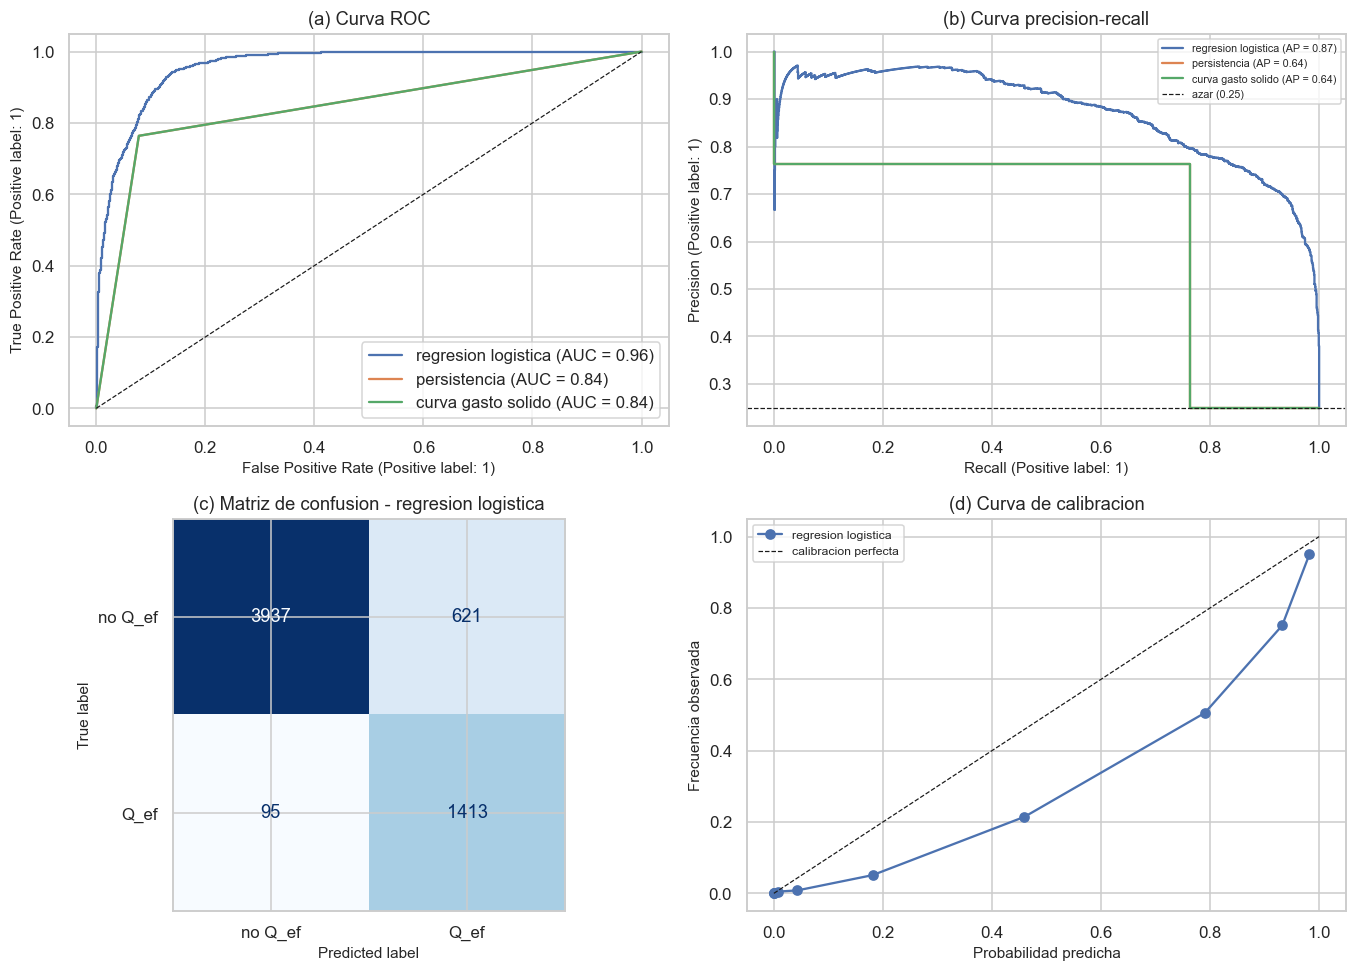

              precision    recall  f1-score   support

     no Q_ef      0.976     0.864     0.917      4558
        Q_ef      0.695     0.937     0.798      1508

    accuracy                          0.882      6066
   macro avg      0.836     0.900     0.857      6066
weighted avg      0.906     0.882     0.887      6066



In [42]:
# --- curvas ROC, precision-recall, matriz de confusion y calibracion ---
yp_l, ys_l = preds["regresion logistica"]
fig, ax = plt.subplots(2, 2, figsize=(12.5, 9))

for nom in ["regresion logistica","persistencia","curva gasto solido"]:
    RocCurveDisplay.from_predictions(yte, preds[nom][1], name=nom, ax=ax[0,0])
ax[0,0].plot([0,1],[0,1],"k--",lw=.8); ax[0,0].set_title("(a) Curva ROC")

for nom in ["regresion logistica","persistencia","curva gasto solido"]:
    PrecisionRecallDisplay.from_predictions(yte, preds[nom][1], name=nom, ax=ax[0,1])
ax[0,1].axhline(yte.mean(), color="k", ls="--", lw=.8, label=f"azar ({yte.mean():.2f})")
ax[0,1].set_title("(b) Curva precision-recall"); ax[0,1].legend(fontsize=7)

ConfusionMatrixDisplay(confusion_matrix(yte, yp_l),
    display_labels=["no Q_ef","Q_ef"]).plot(ax=ax[1,0], cmap="Blues", colorbar=False)
ax[1,0].set_title("(c) Matriz de confusion - regresion logistica")

pt, pp = calibration_curve(yte, np.clip(ys_l,0,1), n_bins=10, strategy="quantile")
ax[1,1].plot(pp, pt, "o-", label="regresion logistica")
ax[1,1].plot([0,1],[0,1],"k--",lw=.8,label="calibracion perfecta")
ax[1,1].set(xlabel="Probabilidad predicha", ylabel="Frecuencia observada",
            title="(d) Curva de calibracion"); ax[1,1].legend(fontsize=8)
plt.tight_layout(); plt.savefig(FIGURAS/"evaluacion.png", dpi=150); plt.show()

print(classification_report(yte, yp_l, target_names=["no Q_ef","Q_ef"], digits=3))

In [43]:
# --- intervalos de confianza bootstrap (exigidos por el entregable) ---
def ic_bootstrap(yt, ys, metrica, n_boot=2000, alfa=0.05):
    rng = np.random.default_rng(SEED)
    yt, ys = np.asarray(yt), np.asarray(ys); v = []
    for _ in range(n_boot):
        i = rng.integers(0, len(yt), len(yt))
        if len(np.unique(yt[i])) < 2: continue
        v.append(metrica(yt[i], ys[i]))
    lo, hi = np.percentile(v, [100*alfa/2, 100*(1-alfa/2)])
    return np.mean(v), lo, hi

print("INTERVALOS DE CONFIANZA BOOTSTRAP AL 95% (2.000 remuestreos)\n")
f = []
for nom in ["dummy (trivial)","persistencia","curva gasto solido","regresion logistica"]:
    yp_, ys_ = preds[nom]
    for met, fn in [("ROC-AUC", roc_auc_score), ("PR-AUC", average_precision_score),
                    ("F1", lambda a,b: f1_score(a, (np.asarray(b)>=0.5).astype(int), zero_division=0))]:
        m_, lo, hi = ic_bootstrap(yte, ys_, fn)
        f.append({"modelo": nom, "metrica": met, "estimacion": m_,
                  "IC95_inf": lo, "IC95_sup": hi})
ics = pd.DataFrame(f).pivot(index="modelo", columns="metrica",
                            values=["estimacion","IC95_inf","IC95_sup"])
print(pd.DataFrame(f).round(4).to_string(index=False))

INTERVALOS DE CONFIANZA BOOTSTRAP AL 95% (2.000 remuestreos)



             modelo metrica  estimacion  IC95_inf  IC95_sup
    dummy (trivial) ROC-AUC      0.5000    0.5000    0.5000
    dummy (trivial)  PR-AUC      0.2486    0.2379    0.2593
    dummy (trivial)      F1      0.0000    0.0000    0.0000
       persistencia ROC-AUC      0.8429    0.8318    0.8545
       persistencia  PR-AUC      0.6425    0.6195    0.6641
       persistencia      F1      0.7640    0.7465    0.7804
 curva gasto solido ROC-AUC      0.8429    0.8318    0.8545
 curva gasto solido  PR-AUC      0.6425    0.6195    0.6641
 curva gasto solido      F1      0.7640    0.7465    0.7804
regresion logistica ROC-AUC      0.9588    0.9545    0.9631
regresion logistica  PR-AUC      0.8722    0.8544    0.8884
regresion logistica      F1      0.7979    0.7834    0.8116


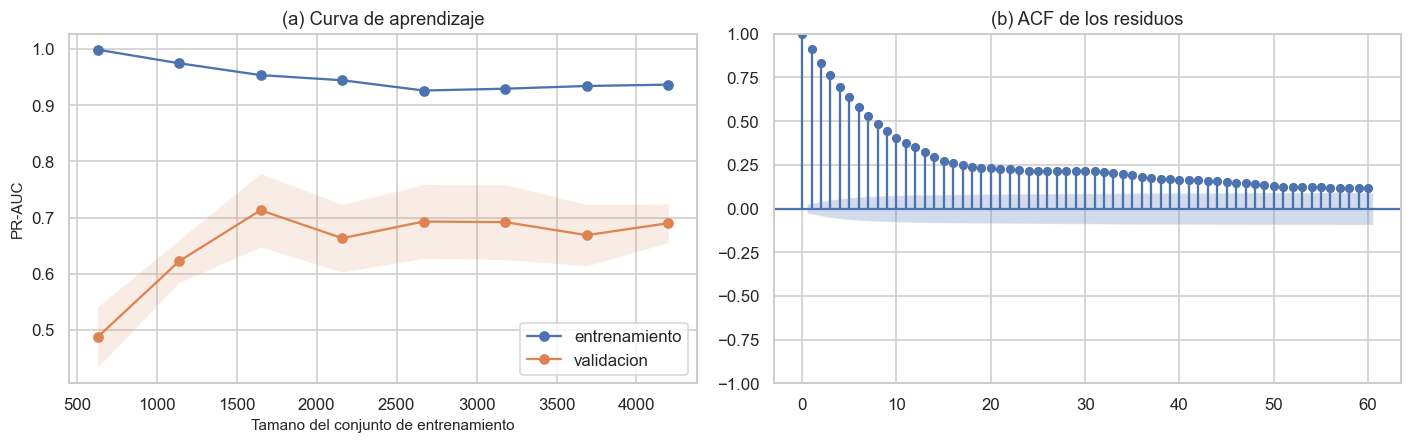

ACF de residuos: lag1 = 0.9142 | lag7 = 0.5273 | lag30 = 0.2129
Residuos con autocorrelacion elevada indican estructura temporal que el
modelo base, por su forma lineal, no logra capturar.


In [44]:
# --- curva de aprendizaje: suficiencia de muestra y sobreajuste ---
tam, sc_tr, sc_va = learning_curve(
    pipeline_logistica(), Xtr, ytr, cv=cv_temporal, scoring="average_precision",
    train_sizes=np.linspace(0.15, 1.0, 8), n_jobs=1, random_state=SEED)

fig, ax = plt.subplots(1, 2, figsize=(13, 4.2))
ax[0].plot(tam, sc_tr.mean(1), "o-", label="entrenamiento")
ax[0].plot(tam, sc_va.mean(1), "o-", label="validacion")
ax[0].fill_between(tam, sc_tr.mean(1)-sc_tr.std(1), sc_tr.mean(1)+sc_tr.std(1), alpha=.15)
ax[0].fill_between(tam, sc_va.mean(1)-sc_va.std(1), sc_va.mean(1)+sc_va.std(1), alpha=.15)
ax[0].set(xlabel="Tamano del conjunto de entrenamiento", ylabel="PR-AUC",
          title="(a) Curva de aprendizaje"); ax[0].legend()

# ACF de los residuos: dependencia temporal no capturada
resid = yte.values - np.clip(ys_l, 0, 1)
from statsmodels.graphics.tsaplots import plot_acf
plot_acf(resid, lags=60, ax=ax[1]); ax[1].set_title("(b) ACF de los residuos")
plt.tight_layout(); plt.savefig(FIGURAS/"aprendizaje_residuos.png", dpi=150); plt.show()

from statsmodels.tsa.stattools import acf as _acf3
ar = _acf3(resid, nlags=30, fft=True)
print(f"ACF de residuos: lag1 = {ar[1]:.4f} | lag7 = {ar[7]:.4f} | lag30 = {ar[30]:.4f}")
print("Residuos con autocorrelacion elevada indican estructura temporal que el")
print("modelo base, por su forma lineal, no logra capturar.")

In [45]:
# --- interpretacion de coeficientes ---
mdl = pipeline_logistica().fit(Xtr, ytr)
coef = pd.DataFrame({"variable": TODAS, "coeficiente": mdl.named_steps["clf"].coef_[0]})
coef["abs"] = coef.coeficiente.abs()
coef["odds_ratio"] = np.exp(coef.coeficiente)
top = coef.nlargest(15, "abs").drop(columns="abs")
print("LAS 15 VARIABLES MAS INFLUYENTES (coeficientes sobre variables estandarizadas)\n")
print(top.round(4).to_string(index=False))

LAS 15 VARIABLES MAS INFLUYENTES (coeficientes sobre variables estandarizadas)

     variable  coeficiente  odds_ratio
dist_qef_lag7       4.5260     92.3866
     dist_qef      -3.9747      0.0188
 dist_qef_rel      -3.9747      0.0188
 calamar_med7       2.5993     13.4550
calamar_med90       2.1014      8.1773
 calamar_lag7       1.8376      6.2815
 calamar_cuad      -1.6346      0.1950
calamar_lag30      -1.4795      0.2278
 calamar_lag5      -1.4253      0.2404
 calamar_lag2      -1.2783      0.2785
calamar_med30       1.1031      3.0136
 calamar_lag1       0.9123      2.4900
calamar_lag60      -0.8910      0.4103
san_roque_rel       0.8111      2.2503
san_roque_t10      -0.7924      0.4528


DESEMPENO SEGUN EL HORIZONTE  (banda +/-15%)



PR-AUC por horizonte:

predictores  con variables de dominio  persistencia  solo lineales
horizonte                                                         
t+1                            0.9960        0.9621         0.4814
t+7                            0.9548        0.8011         0.4834
t+15                           0.8717        0.6423         0.4867
t+30                           0.6287        0.4395         0.4762
t+60                           0.4832        0.2705         0.4591


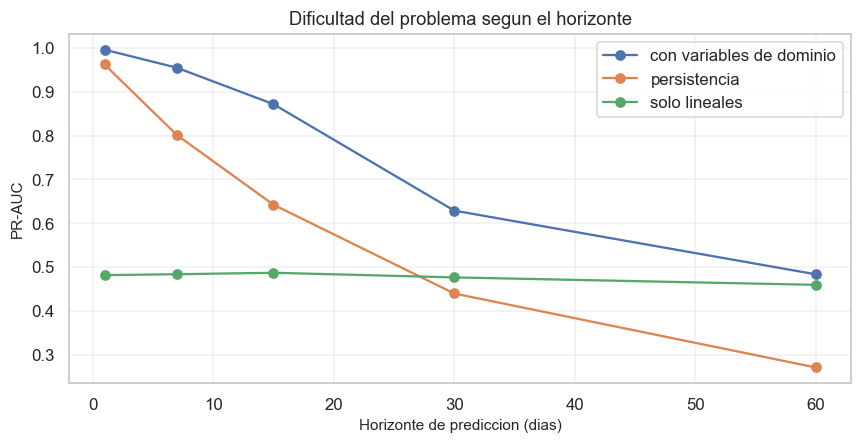

In [46]:
# --- sensibilidad al horizonte de prediccion ---
print("DESEMPENO SEGUN EL HORIZONTE  (banda +/-15%)\n")
f = []
for h in (1, 7, 15, 30, 60):
    z = dfx.copy()
    z["y"] = z[ESTACION_OBJETIVO].between(*LIM).astype(float).shift(-h)
    z = z.dropna(subset=["y"])
    a_ = z[z.fecha < corte]; b_ = z[z.fecha >= inicio_test]
    for nom, cols in [("solo lineales", BASE_COLS), ("con variables de dominio", TODAS)]:
        m_ = pipeline_logistica().fit(a_[cols], a_.y.astype(int))
        s_ = m_.predict_proba(b_[cols])[:,1]
        f.append({"horizonte": f"t+{h}", "predictores": nom,
                  "ROC_AUC": roc_auc_score(b_.y.astype(int), s_),
                  "PR_AUC": average_precision_score(b_.y.astype(int), s_)})
    pm = Persistencia(LIM)
    f.append({"horizonte": f"t+{h}", "predictores": "persistencia",
              "ROC_AUC": roc_auc_score(b_.y.astype(int), pm.predict_proba(b_)[:,1]),
              "PR_AUC": average_precision_score(b_.y.astype(int), pm.predict_proba(b_)[:,1])})
sens = pd.DataFrame(f).pivot(index="horizonte", columns="predictores",
                             values="PR_AUC").reindex([f"t+{h}" for h in (1,7,15,30,60)])
print("PR-AUC por horizonte:\n")
print(sens.round(4).to_string())

fig, ax = plt.subplots(figsize=(8, 4.2))
for c in sens.columns: ax.plot([1,7,15,30,60], sens[c], "o-", label=c)
ax.set(xlabel="Horizonte de prediccion (dias)", ylabel="PR-AUC",
       title="Dificultad del problema segun el horizonte")
ax.legend(); ax.grid(alpha=.3)
plt.tight_layout(); plt.savefig(FIGURAS/"horizonte.png", dpi=150); plt.show()

## 3.4 Nota critica

> El entregable advierte que un desempeno alto (*accuracy* $\geq$ 80-90 %) debe
> verificarse antes de aceptarse. Se aplica la lista completa.

| Verificacion | Resultado en este trabajo |
|---|---|
| **Fuga de datos** | Auditada en 2.5. El objetivo esta en $t+15$ y todo predictor usa solo informacion hasta $t$. Se detecto y **excluyo** la serie de transporte por ser funcion determinista del caudal (2.1.1) |
| **Comparacion con la linea base trivial** | Realizada. Ademas se anaden **dos referencias de dominio mas exigentes** |
| **La validacion respeta la estructura temporal** | Particion cronologica con `gap` de 30 dias y `TimeSeriesSplit`; nunca aleatoria |
| **Complejidad del dataset** | 86 anos, 7 estaciones, regimen bimodal y fuerte autocorrelacion |
| **El problema es trivial?** | **A horizonte corto, si.** Por eso se adopto $h=15$ y se reporta la curva completa de desempeno frente al horizonte |

### 3.4.1 El riesgo especifico de este problema: la persistencia

El caudal diario de un rio grande es **muy persistente** (ACF(15) = 0,92 segun 2.6).
Predecir a un dia vista es casi trivial: basta repetir el estado actual. Esto **no es fuga
de datos** -el caudal de hoy si esta disponible hoy- pero volveria el ejercicio vacio.

Por ello: (i) se fijo el horizonte en **15 dias**, (ii) se incluyo la **persistencia como
linea base**, y (iii) se reporta la **sensibilidad al horizonte**, que muestra como el
problema se vuelve genuinamente dificil al alejarse en el tiempo. Esa curva es un
resultado mas informativo que cualquier cifra aislada.

## 3.6 Hallazgo: por que un modelo lineal es inadecuado para este objetivo

La variable objetivo es una **banda**: el dia es positivo si
$Q_{t+15} \in [8.461,\ 11.448]$ m3/s.

**Una banda no es representable con una frontera lineal.** La regresion logistica modela
el logit como funcion **monotona** de cada predictor: solo puede afirmar "a mayor caudal,
mayor probabilidad". Pero la clase positiva exige que el caudal **no sea ni muy alto ni
muy bajo**, condicion **no monotona**.

La solucion adoptada es de **ingenieria de caracteristicas motivada por el dominio**:
sustituir $Q_t$ por la **distancia** $\lvert Q_t - Q_{ef}\rvert$. Esa transformacion
convierte el problema no monotono en uno monotono -"a menor distancia, mayor
probabilidad"- que el modelo lineal si puede expresar. La tabla de sensibilidad al
horizonte cuantifica la ganancia.

> **Interpretacion.** La limitacion no estaba en los datos sino en la **forma funcional**
> del modelo base. Esto justifica explorar en el siguiente entregable algoritmos capaces
> de fronteras no monotonas: **k-NN, arboles de decision y SVM con nucleo RBF**. La
> autocorrelacion remanente en los residuos apunta en la misma direccion.

---
# 4. Conclusiones y limitaciones

## 4.1 Hallazgos principales del EDA

1. **La serie de transporte de sedimentos de IDEAM no es una medicion independiente.**
   Se demostro que es el caudal transformado por una curva de gasto solido, con $R^2 = 1$
   dentro de cada bloque quinquenal, y que IDEAM cambio esa curva al menos cuatro veces.
   Las evidencias corroborantes son la persistencia del residuo (ACF(1) = 0,999) y la
   **ausencia de histeresis** entre ramas del hidrograma. *Decision derivada:* se excluyo
   del modelo y se uso la curva oficial solo para localizar $Q_{ef}$.

2. **La descarga efectiva de Calamar es de aproximadamente 9.954 m3/s**, equivalente a
   1,38 veces el caudal medio. El resultado es **robusto**: las cuatro curvas historicas
   conducen a la misma clase modal.

3. **El rio se comporta como dos sistemas debilmente acoplados.** El alto Magdalena
   correlaciona fuertemente consigo mismo pero debilmente con Calamar; el bajo Magdalena
   correlaciona fuertemente con la estacion objetivo. El PCA lo confirma: la segunda
   componente opone ambos grupos. La explicacion es geomorfologica (aportes del Cauca y
   el Cesar, y amortiguacion en la depresion momposina). *Decision derivada:* justifica
   tratar la multicolinealidad como resultado fisico y no como defecto.

4. **El tiempo de transito de la onda de crecida crece monotonamente con la distancia**,
   de 7 dias desde Coyongal a 21 desde Puerto Salgar, y la correlacion **aumenta** al
   aplicar el desfase. *Decision derivada:* cada estacion entra al modelo con su rezago
   empirico, no con uno arbitrario.

5. **El caudal en Calamar es casi simetrico** (asimetria 0,26), a diferencia de las
   estaciones de aguas arriba. *Decision derivada:* **no** se aplica transformacion
   logaritmica, decision contraria a la practica habitual y sustentada en evidencia.

## 4.2 Desempeno del modelo base

Los resultados completos figuran en la seccion 3, con intervalos de confianza bootstrap.
El elemento central es la comparacion frente a **tres** referencias, y muy especialmente
frente a la **persistencia**, que es la barra exigente en series hidrologicas.

## 4.3 Limitaciones declaradas

- **Serie de transporte inhomogenea.** El cambio de curva entre periodos invalida
  cualquier analisis de tendencia sedimentaria de largo plazo sobre esos datos.
- **Nivel de aprobacion.** El 89,6 % del registro figura como `Preliminar`; restringir a
  `Definitivo` dejaria ~3.200 observaciones, por debajo del minimo exigido.
- **Tamano efectivo de muestra.** Con ACF(1) = 0,999, las 31.475 filas equivalen a un
  numero de observaciones independientes varios ordenes de magnitud menor.
- **Cobertura temporal desigual.** El periodo 1940-1972 esta representado solo por dos
  estaciones; Arrancaplumas se excluyo del modelo por terminar en 2014.
- **Ausencia de variables meteorologicas.** Sin precipitacion, el sistema de predictores
  es esencialmente hidrologico y carece de informacion sobre la **causa** del caudal. Es
  la limitacion mas relevante a horizontes largos.
- **Variables no observadas.** Las diferencias entre estaciones podrian reflejar
  contrastes de suelo y cobertura vegetal en sus cuencas aportantes; este diseno no
  permite separar ese efecto del efecto de la posicion en el cauce.
- **Estacionariedad.** La regulacion por embalses y los cambios de uso del suelo implican
  que el pasado puede no representar el futuro (*concept drift*).
- **Extrapolacion espacial.** Los resultados aplican a Calamar y a las estaciones
  analizadas, no a la totalidad de la cuenca Magdalena-Cauca.

## 4.4 Proximos pasos

1. Incorporar **precipitacion** y el **indice ENSO** como predictores de causa, cuyo
   aporte deberia concentrarse en los horizontes largos.
2. Evaluar modelos con **fronteras no monotonas** (k-NN, arboles, SVM-RBF), segun motiva
   el hallazgo 3.6.
3. Aplicar **regularizacion** (Ridge y Lasso) para estabilizar los coeficientes ante la
   multicolinealidad documentada en 2.3.1.
4. Explorar la hipotesis de que la **deforestacion** de la cuenca alta modifique la
   respuesta lluvia-caudal y, con ella, el regimen de transporte.

---

## Referencias

- Wolman, M. G., & Miller, J. P. (1960). Magnitude and frequency of forces in geomorphic
  processes. *The Journal of Geology*, 68(1), 54-74.
- Restrepo, J. D., & Kjerfve, B. (2000). Magdalena river: interannual variability
  (1975-1995) and revised water discharge and sediment load estimates.
  *Journal of Hydrology*, 235(1-2), 137-149.
- IDEAM. Sistema de Informacion Ambiental de Colombia, portal DHIME.
  http://dhime.ideam.gov.co
- Pedregosa, F. et al. (2011). Scikit-learn: Machine Learning in Python.
  *Journal of Machine Learning Research*, 12, 2825-2830.